<a href="https://colab.research.google.com/github/ks-1019/RnT-Particle-Potentials/blob/main/rntpotentials_astumianbier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

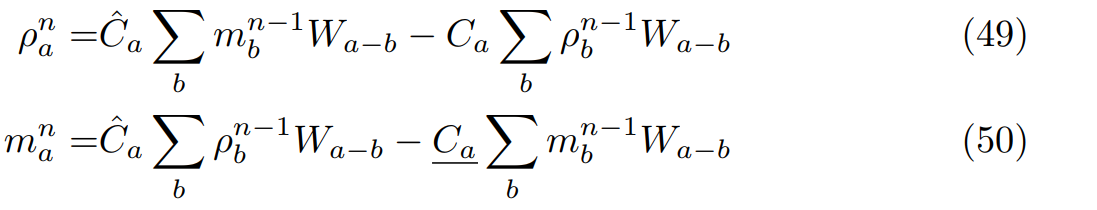

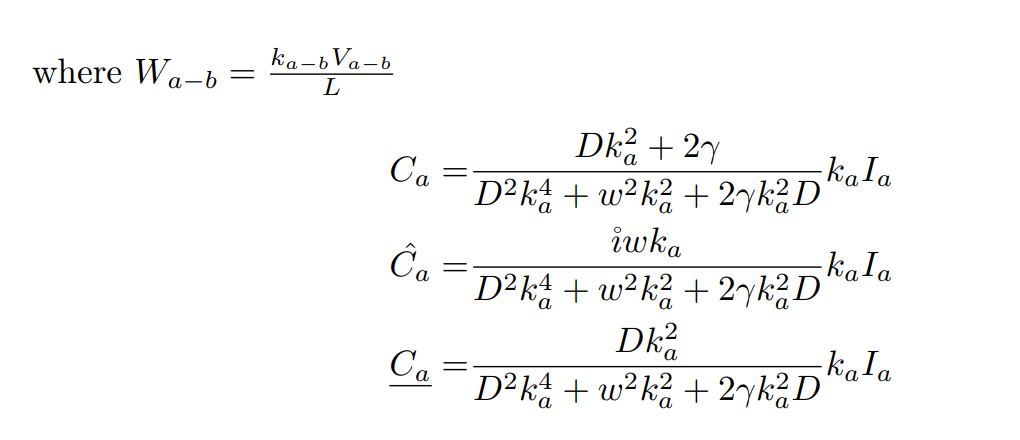

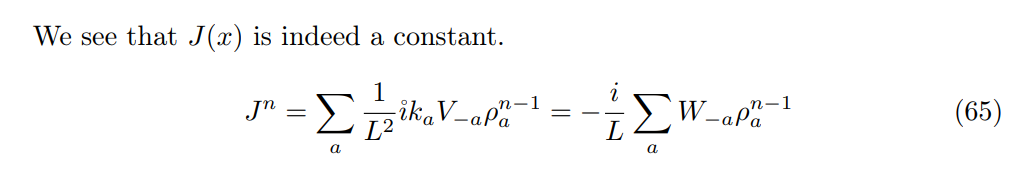

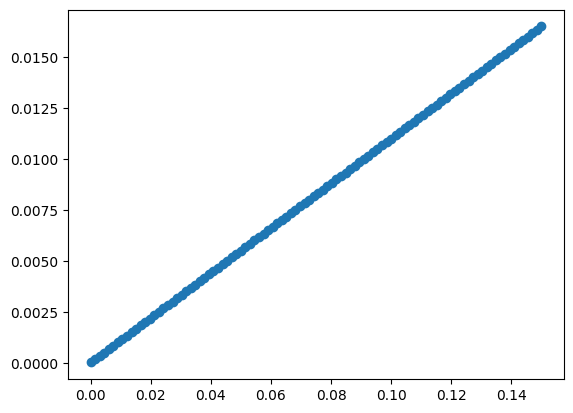

Fourier modes tracked: 10001 (from -5000 to 5000)
Steady-State Current J = 1.1186625328347527e-06
Magnitude of Current |J| = 0.000001


In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def initialise_modes(A, alpha, E_0=1.0, L=1.0):
  a_indices = np.arange(-A,A+1) # shifted array
  U = np.zeros_like(a_indices, dtype=complex)

  for i, a in enumerate(a_indices):
    if a == 0:
      U[i] = E_0 / 2
    else:
      U[i] = E_0 * (np.exp(-2*np.pi*1j*a*alpha) - 1) / (4 * np.pi**2 * a**2 * (1-alpha) * alpha)

# have to enforce this for every potential
  for a in a_indices:
    if a > 0:
      i = np.where(a_indices==a)[0][0]
      j = np.where(a_indices==-a)[0][0]
      U[j] = np.conjugate(U[i])
# plot the potential graph
  x_vals = np.linspace(0.0,0.15, 100)
  U_vals = []
  for x in x_vals:
     u = sum([U[i] * np.exp(1j * 2 * np.pi * a * x) for i, a in enumerate(a_indices)])
     U_vals.append(u)
  plt.plot(x_vals, np.real(U_vals),'o')
  plt.show()

# below is for sawtooth potential which is symmetric about the origin
  # i1 = np.where(a_indices==1)[0][0]
  # U[i1] = 1j * np.imag(U[i1]) # removed the real part as U_1 fixed as purely imaginary
  return a_indices, U

def pade_approx(coeffs, L, M):
  # Solves the Padé system of equations to find polynomials P and Q such that P(x)/Q(x) matches the Taylor series coefficients.
  # We have to use the Padé approximation method later as otherwise the current series diverges.
  # we do this using lin alg - finding p_L/q_M (p_L, q_M polys of nu)

  # STEP 1: SOLVING FOR q_M - coeffs are the coefficients of the Taylor series we put in the func
  A = np.zeros((M,M))
  b = np.zeros(M)
  for i in range(M):
    n = L + i + 1
    for k in range(1,M+1):
      if 0 <= (n-k) < len(coeffs):
        A[i, k-1] = coeffs[n-k]
    if n < len(coeffs):
      b[i] = -coeffs[n]

  q_vars = np.linalg.solve(A, b) # Aq = b
  # q0 = 1.0 so we put that at beginning
  q = np.insert(q_vars, 0, 1.0)

  # STEP 2: SOLVING FOR p_L - straightforward now we have q vals
  p = np.zeros(L + 1)
  for n in range(L + 1):
    for k in range(min(n + 1, M + 1)):
        p[n] += q[k] * coeffs[n-k]

  return p,q

def current_series(a_indices, U_modes, D, w, L, gamma, N_nu, nu):
  N = len(a_indices) # 2A+1
  k_vals = 2.0 * np.pi * a_indices / L
  # we define a matrix with all of the W_a-b values for efficiency since it comes up a lot
  W = np.zeros((N,N), dtype=complex)
  for i, a in enumerate(a_indices):
    for j, b in enumerate(a_indices):
      diff = a-b
      if diff in a_indices:
        idx = np.where(a_indices == diff)[0][0]
        W[i][j] = k_vals[idx]*U_modes[idx]/L
  # calculate the Fourier coefficients C_a, C^_a, C_a_ (total field component, dissipative component, diffusive component)
  C = np.zeros(N, dtype=complex)
  C_hat = np.zeros(N, dtype=complex)
  C_under = np.zeros(N, dtype=complex)

  for i, a in enumerate(a_indices):
    if a == 0:
        C[i] = 0.0
        C_hat[i] = 0.0
        C_under[i] = 0.0
    else:
      denom = D**2 * k_vals[i]**4 + w**2 * k_vals[i]**2 + 2 * gamma * k_vals[i]**2 * D
      I_a = 1.0 if a != 0 else 0.0
      C[i] = (D*k_vals[i]**2 + 2*gamma) * k_vals[i] * I_a / denom
      C_hat[i] = 1j * w * k_vals[i]**2 * I_a / denom
      C_under[i] = D*k_vals[i]**2 * k_vals[i] * I_a / denom

# Initialize order-0 fields: rho^0 has mass 1 at mode 0, m^0 is entirely 0
  rho = np.zeros(N, dtype=complex)
  m = np.zeros(N, dtype=complex)
  if 0 in a_indices:
      zero_idx = np.where(a_indices == 0)[0][0]
      rho[zero_idx] = 1.0

    # Construct the current extraction vector (W_{-a})
  W_minus_a = np.zeros(N, dtype=complex)
  for i, a in enumerate(a_indices):
      if -a in a_indices:
          idx = np.where(a_indices == -a)[0][0]
          W_minus_a[i] = k_vals[idx] * U_modes[idx] / L

  # initialise for running total - so we can collect J terms in an array (N_nu of them)
  # (this is for Pade approximation to evaluate total of J series)
  J_0 = 0.0
  J_1 = (-1j / L) * np.dot(W_minus_a, rho)
  coeffs = [J_0, J_1.real]

    # To calculate the n-th order current J^n, we need the (n-1)-th order density rho^{n-1}.
    # Therefore, we iterate the coupled recurrence relations from order 1 up to order n-1.
  for order in range(1, N_nu):
      sum_m = W @ m
      sum_rho = W @ rho

      # Coupled algebraic transitions from Equations 49 & 50
      rho_next = C_hat * sum_m - C * sum_rho
      m_next = C_hat * sum_rho - C_under * sum_m

      rho = rho_next
      m = m_next

      # works out the next term in current series and adds to running total
      J_next = (-1j / L) * np.dot(W_minus_a, rho)
      coeffs.append(J_next.real) # adding to the terms array

    # Equation 64: J^n = (i / L^2) * sum_a (k_a * V_{-a} * rho_a^{n-1})
    # J^n = sum from 1 to N_nu (nu^n * J^n)
    # Now to implement Pade approx. Near diagonal is best so we use:
  # L_order = N_nu // 2
  # M_order = N_nu - L_order
  # p, q = pade_approx(coeffs, L_order, M_order)

  # J_total = np.polyval(p[::-1], nu) / np.polyval(q[::-1], nu)
  n_array = np.arange(len(coeffs))
  J_total = np.sum(np.array(coeffs) * (nu ** n_array))
  return J_total

# Now the actual simulation.

A_cutoff = 5000     # Number of positive/negative Fourier modes to track (total 2A+1 modes)
L_domain = 1.0    # Length of spatial domain
D_diff   = 1.0    # Translational diffusion coefficient
w_freq   = 1.0    # Angular frequency of temporal oscillations = delta F as well
gamma_rtp = 10.0   # Tumbling rate (1 / persistence time)
N_nu_val = 2000   # perturbation order (no. of terms in current series)
E_0 = 0.1
nu_height = 1.0
alpha = 10/11

a_indices, U_modes = initialise_modes(A=A_cutoff, L=L_domain, alpha=alpha, E_0=E_0)


J_result = current_series(
    a_indices=a_indices,
    U_modes=U_modes,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height
)

print(f"Fourier modes tracked: {len(a_indices)} (from {-A_cutoff} to {A_cutoff})")
print(f"Steady-State Current J = {J_result}")
print(f"Magnitude of Current |J| = {abs(J_result):.6f}")

# plot a graph of log gamma vs J
gamma_vals = np.logspace(-2, 2, 50)  # e.g. γ from 1e-2 to 1e2
J_vals = []

for gamma in gamma_vals:
    J = current_series(
        a_indices=a_indices,
        U_modes=U_modes,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma,
        N_nu=N_nu_val,
        nu=nu_height
    )
    J_vals.append(J.real)  # or abs(J) if you must

log_gamma = np.log(gamma_vals)

plt.plot(gamma_vals, J_vals)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$J$')
plt.axhline(0, color='k', linewidth=0.5)
plt.show()

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg

OUTPUT_DIR = Path.cwd() / "outputs"

# -----------------------------
# Transfer-matrix (Eq. 3 ansatz)
# -----------------------------

def interval_forces(case, interval, a, e0, delta):
    """Piecewise constant forces for force/barrier fluctuation."""
    if interval == 1:
        base = -e0 / a
    else:
        base = e0 / (1.0 - a)

    if case == "force":
        # dU/dx -> dU/dx +/- DeltaF, so F=-dU/dx -> F0 -/+ DeltaF.
        return base - delta, base + delta

    if case == "barrier":
        # E0 -> E0 +/- DeltaE modifies slopes.
        if interval == 1:
            return -(e0 + delta) / a, -(e0 - delta) / a
        return (e0 + delta) / (1.0 - a), (e0 - delta) / (1.0 - a)

    raise ValueError("case must be 'force' or 'barrier'")

def interval_matrix(force_plus, force_minus, gamma):
    """4D first-order system in terms of P+-, J+-."""
    return np.array(
        [
            [force_plus, 0.0, -1.0, 0.0],
            [0.0, force_minus, 0.0, -1.0],
            [-gamma, gamma, 0.0, 0.0],
            [gamma, -gamma, 0.0, 0.0],
        ],
        dtype=float,
    )

def augmented_matrix(force_plus, force_minus, gamma):
    """Augment with a row that integrates P+ + P- over one interval."""
    a4 = interval_matrix(force_plus, force_minus, gamma)
    aug = np.zeros((5, 5), dtype=float)
    aug[:4, :4] = a4
    aug[4, 0] = 1.0
    aug[4, 1] = 1.0
    return aug

def interval_transfer(force_plus, force_minus, gamma, length):
    """Transfer matrix over a spatial interval of given length."""
    return scipy.linalg.expm(augmented_matrix(force_plus, force_minus, gamma) * length)

def stationary_current_ansatz(case, gamma, a=10.0 / 11.0, e0=10.0, delta=1.0):
    """Stationary current from stable Eq. 3 ansatz, one-period transfer."""
    length1 = a
    length2 = 1.0 - a
    f1p, f1m = interval_forces(case, 1, a, e0, delta)
    f2p, f2m = interval_forces(case, 2, a, e0, delta)

    t1 = interval_transfer(f1p, f1m, gamma, length1)
    t2 = interval_transfer(f2p, f2m, gamma, length2)
    total = t2 @ t1

    monodromy = total[:4, :4]
    integral_row = total[4, :4]
    homogeneous = monodromy - np.eye(4)

    candidates = []
    for drop in range(4):
        keep = [i for i in range(4) if i != drop]
        system = np.vstack([homogeneous[keep, :], integral_row])
        rhs = np.array([0.0, 0.0, 0.0, 1.0])
        try:
            y = np.linalg.solve(system, rhs)
        except np.linalg.LinAlgError:
            y, *_ = np.linalg.lstsq(system, rhs, rcond=None)
        periodic_residual = np.linalg.norm(homogeneous @ y)
        normalization_residual = abs(integral_row @ y - 1.0)
        candidates.append((periodic_residual + normalization_residual,
                           periodic_residual, y))

    _score, residual, y0 = min(candidates, key=lambda item: item[0])
    svals = np.linalg.svd(homogeneous, compute_uv=False)
    total_current = y0[2] + y0[3]
    return float(total_current), float(residual), float(np.min(svals))

def exact_potential(x, a, e0):
    """Piecewise linear ratchet potential."""
    return np.where(x < a, e0 * x / a, e0 * (1.0 - x) / (1.0 - a))

# -----------------------------
# Simple finite-volume solver
# -----------------------------

def fv_force_states(case, x_faces, a, e0, delta):
    """Discretized F+(x), F-(x) on cell faces for given case."""
    # intervals: 0..a and a..1
    mask1 = x_faces < a
    mask2 = ~mask1

    f1p, f1m = interval_forces(case, 1, a, e0, delta)
    f2p, f2m = interval_forces(case, 2, a, e0, delta)

    Fp = np.zeros_like(x_faces)
    Fm = np.zeros_like(x_faces)

    Fp[mask1] = f1p
    Fm[mask1] = f1m
    Fp[mask2] = f2p
    Fm[mask2] = f2m
    return Fp, Fm

def stationary_current_fv(case, gamma, a=10.0 / 11.0, e0=10.0, delta=1.0,
                          n_grid=2200, D=1.0):
    """
    Crude finite-volume discretization of stationary two-state FP.
    This is a simple benchmark for the ansatz; not fully optimized.
    """
    L = 1.0
    dx = L / n_grid
    x_faces = (np.arange(n_grid) + 0.5) * dx

    Fp_faces, Fm_faces = fv_force_states(case, x_faces, a, e0, delta)

    # unknowns: P_plus[i], P_minus[i], i=0..n_grid-1
    N = n_grid
    M = np.zeros((2*N, 2*N))
    b = np.zeros(2*N)

    def idx_p(i):
        return i

    def idx_m(i):
        return N + i

    # periodic indices
    def left(i):
        return (i - 1) % N

    def right(i):
        return (i + 1) % N

    # Build discrete stationary equations: divergence of flux + switching = 0
    for i in range(N):
        ip = idx_p(i)
        im = idx_m(i)

        # neighbors
        il = left(i)
        ir = right(i)

        # fluxes at faces using simple upwind/diffusion
        # J = F P - D dP/dx
        # approximate dP/dx with central diff
        # contribution to divergence: (J_right - J_left)/dx

        # P+ equation
        # at cell i, contributions from neighbors:
        # diffusion + drift + switching
        # -D * (P+(i+1) - 2P+(i) + P+(i-1))/dx^2
        # - (Fp(i+1)-Fp(i-1))/(2dx) * P+(i) approximately
        M[ip, idx_p(il)] += -D / dx**2
        M[ip, idx_p(i)]  +=  2*D / dx**2
        M[ip, idx_p(ir)] += -D / dx**2

        # crude drift term (use local face force)
        kFp = Fp_faces[i]
        # - d/dx(FP) ≈ -kFp * (P(i+1) - P(i-1))/(2dx)
        M[ip, idx_p(ir)] += -kFp / (2*dx)
        M[ip, idx_p(il)] +=  kFp / (2*dx)

        # switching: -gamma P+ + gamma P-
        M[ip, idx_p(i)]  += -gamma
        M[ip, idx_m(i)]  +=  gamma

        # P- equation
        kFm = Fm_faces[i]
        M[im, idx_m(il)] += -D / dx**2
        M[im, idx_m(i)]  +=  2*D / dx**2
        M[im, idx_m(ir)] += -D / dx**2

        M[im, idx_m(ir)] += -kFm / (2*dx)
        M[im, idx_m(il)] +=  kFm / (2*dx)

        M[im, idx_m(i)]  += -gamma
        M[im, idx_p(i)]  +=  gamma

    # normalization: sum_i (P+ + P-) dx = 1
    # replace one row by normalization
    row_norm = 0
    M[row_norm, :] = 0.0
    for i in range(N):
        M[row_norm, idx_p(i)] += dx
        M[row_norm, idx_m(i)] += dx
    b[row_norm] = 1.0

    # solve linear system
    P = np.linalg.lstsq(M, b, rcond=None)[0]
    Pp = P[:N]
    Pm = P[N:]

    # compute current J = J+ + J- on grid (take average)
    Jplus = Fp_faces * Pp - D * (np.roll(Pp, -1) - np.roll(Pp, 1)) / (2*dx)
    Jminus = Fm_faces * Pm - D * (np.roll(Pm, -1) - np.roll(Pm, 1)) / (2*dx)
    J = (Jplus + Jminus).mean()
    return float(J)

# -----------------------------
# Curve generation with masks
# -----------------------------

def make_curves():
    a = 10.0 / 11.0
    e0 = 10.0
    delta = 1.0

    log_gamma = np.linspace(-2.0, 5.0, 95)
    gamma_values = 10.0**log_gamma

    j_force_ans = np.zeros_like(gamma_values)
    j_barrier_ans = np.zeros_like(gamma_values)
    res_force_ans = np.zeros_like(gamma_values)
    res_barrier_ans = np.zeros_like(gamma_values)
    j_force_fv = np.zeros_like(gamma_values)
    j_barrier_fv = np.zeros_like(gamma_values)

    for i, gamma in enumerate(gamma_values):
        jf, rf, _ = stationary_current_ansatz("force", gamma, a, e0, delta)
        jb, rb, _ = stationary_current_ansatz("barrier", gamma, a, e0, delta)
        j_force_ans[i] = jf
        j_barrier_ans[i] = jb
        res_force_ans[i] = rf
        res_barrier_ans[i] = rb

        j_force_fv[i] = stationary_current_fv("force", gamma, a, e0, delta)
        j_barrier_fv[i] = stationary_current_fv("barrier", gamma, a, e0, delta)

    # relative error masks
    force_err = np.abs(j_force_ans - j_force_fv) / np.maximum(np.abs(j_force_fv), 1.0e-8)
    barrier_err = np.abs(j_barrier_ans - j_barrier_fv) / np.maximum(np.abs(j_barrier_fv), 1.0e-8)

    force_mask = (res_force_ans < 1.0e-5) & (force_err < 0.05)
    barrier_mask = (res_barrier_ans < 1.0e-4) & (barrier_err < 0.05)

    return {
        "a": a,
        "e0": e0,
        "delta": delta,
        "log_gamma": log_gamma,
        "gamma": gamma_values,
        "j_force_ans": j_force_ans,
        "j_barrier_ans": j_barrier_ans,
        "j_force_fv": j_force_fv,
        "j_barrier_fv": j_barrier_fv,
        "force_mask": force_mask,
        "barrier_mask": barrier_mask,
    }

# -----------------------------
# Plot to match ansatz-cross-check
# -----------------------------

def plot_results(results):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_DIR / "09_prl_fig2_ansatz_vs_finite_volume.png"

    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))

    # Left: potential
    x = np.linspace(0.0, 1.0, 1200)
    u = exact_potential(x, results["a"], results["e0"])
    axes[0].plot(x, u, color="black", lw=2.0)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("U(x)")
    axes[0].set_title(r"Astumian-Bier ratchet: $a = 10/11$, $E_0 = 10$")
    axes[0].grid(True, alpha=0.25)

    # Right: finite-volume lines + ansatz markers
    lg = results["log_gamma"]

    axes[1].plot(
        lg,
        results["j_force_fv"],
        color="tab:blue",
        lw=2.0,
        label="force, finite-volume",
    )
    axes[1].plot(
        lg[results["force_mask"]],
        results["j_force_ans"][results["force_mask"]],
        "o",
        ms=3.0,
        color="black",
        label="force, Eq. 3 ansatz",
    )

    axes[1].plot(
        lg,
        results["j_barrier_fv"],
        color="tab:orange",
        lw=2.0,
        label="barrier, finite-volume",
    )
    axes[1].plot(
        lg[results["barrier_mask"]],
        results["j_barrier_ans"][results["barrier_mask"]],
        "s",
        ms=3.0,
        color="black",
        label="barrier, Eq. 3 ansatz",
    )

    axes[1].axhline(0.0, color="black", lw=0.8)
    axes[1].set_xlim(-2, 5)
    axes[1].set_xlabel(r"$\log_{10} \gamma$")
    axes[1].set_ylabel("J")
    axes[1].set_title("PRL Fig. 2: ansatz cross-check")
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].grid(True, alpha=0.25)

    fig.tight_layout()
    fig.savefig(path, dpi=220)
    plt.show()
    return path

# -----------------------------
# Run
# -----------------------------

results = make_curves()
path = plot_results(results)
print("Saved:", path)

KeyboardInterrupt: 

In [ ]:
# plan of optimisation: given a set of parameters:
# we are optimising over the potential as a Fourier series - take the first 5, optimise, then take some more, optimise, etc
# max current occurs right before convergence stops - so BE CAREFUL
# BOREL RESUMMATION

# 1. Optimise shape normally
# 2. Use Borel resummations by defining an f(z) then optimising using that
# 3. Use MPC package to do it more powerfully

Baseline J:  -1.3089633193993201e-18
[0.0, 0.0, np.float64(7.395570986446986e-32), np.float64(-3.1761839391097606e-18), np.float64(1.6948183510607676e-32), np.float64(2.9919253446341846e-18), np.float64(-1.5407439555097887e-33), np.float64(-1.5875313707164141e-18), np.float64(-3.851859888774472e-34), np.float64(6.070727306700523e-19), np.float64(2.8888949165808538e-34), np.float64(-1.7862315668787386e-19)]
N_nu=5, J=-1.842585944754851e-19
N_nu=10, J=-1.1647172345218485e-18
N_nu=15, J=-1.30898058125851e-18
N_nu=20, J=-1.3089633193993201e-18
N_nu=25, J=-1.3091787809610629e-18
N_nu=30, J=-1.309176687237356e-18


KeyboardInterrupt: 

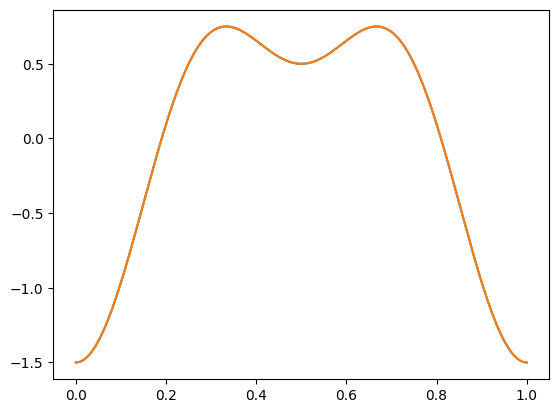

In [ ]:
# Optimiser code

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# using Gunnar's two-mode baseline potential
def initialise_modes(A, E_0=1.0, L=1.0): # base shape generator
  a_indices_full = np.arange(-A,A+1) # shifted array
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  # build a simple two-mode asymmetric sine benchmark matching the C code:
  amplitudes = np.array([1.0, 0.5])
  phases = np.array([-np.pi/2, -np.pi/2])
  for n in range(1, len(amplitudes) + 1):
    A_n = amplitudes[n-1]
    phi_n = phases[n-1]
    U_n = (L / 2.0) * A_n * np.exp(1j * (phi_n - np.pi / 2))
    U_base[a_indices_full == n] = U_n
    U_base[a_indices_full == -n] = np.conjugate(U_n)

# Hard-code a simple asymmetric ratchet directly in complex form
#def initialise_modes(A, E_0=1.0, L=1.0):
 # a_indices_full = np.arange(-A, A+1)
#  U_base = np.zeros_like(a_indices_full, dtype=complex)
  # Simple benchmark: purely imaginary modes
 # U_base[a_indices_full == 1] = -1.0j
  #U_base[a_indices_full == -1] = 1.0j
 # U_base[a_indices_full == 2] = -0.5j
 # U_base[a_indices_full == -2] = 0.5j
 # return a_indices_full, U_base

# plot the potential graph
  x_vals = np.linspace(0, L, 200)
  U_vals = np.sum(U_base[:, None] * np.exp(1j * 2*np.pi * a_indices_full[:,None] * x_vals[None, :] / L), axis=0) / L
  plt.plot(x_vals, np.real(U_vals), label='Re(U)')
# below is for sawtooth potential which is symmetric about the origin
  # i1 = np.where(a_indices==1)[0][0]
  # U[i1] = 1j * np.imag(U[i1]) # removed the real part as U_1 fixed as purely imaginary
  return a_indices_full, U_base

def pade_approx(coeffs, L, M):
  # Solves the Padé system of equations to find polynomials P and Q such that P(x)/Q(x) matches the Taylor series coefficients.
  # We have to use the Padé approximation method later as otherwise the current series diverges.
  # we do this using lin alg - finding p_L/q_M (p_L, q_M polys of nu)

  # STEP 1: SOLVING FOR q_M - coeffs are the coefficients of the Taylor series we put in the func
  A = np.zeros((M,M))
  b = np.zeros(M)
  for i in range(M):
    n = L + i + 1
    for k in range(1,M+1):
      if 0 <= (n-k) < len(coeffs):
        A[i, k-1] = coeffs[n-k]
    if n < len(coeffs):
      b[i] = -coeffs[n]

  q_vars = np.linalg.solve(A, b) # Aq = b
  # q0 = 1.0 so we put that at beginning
  q = np.insert(q_vars, 0, 1.0)

  # STEP 2: SOLVING FOR p_L - straightforward now we have q vals
  p = np.zeros(L + 1)
  for n in range(L + 1):
    for k in range(min(n + 1, M + 1)):
        p[n] += q[k] * coeffs[n-k]

  return p,q

def U_modes(theta, U_base, A_k, a_indices_full):
  U_modes = U_base.copy()
  for a in range(1, A_k+1):
    i = np.where(a_indices_full == a)[0][0]
    j = np.where(a_indices_full == -a)[0][0]
    re = theta[2 * (a-1)]
    im = theta[2 * (a-1) + 1]
    U_modes[i] = re + 1j * im
    U_modes[j] = np.conjugate(U_modes[i])
  return U_modes

def current_series(a_indices, U_modes, D, w, L, gamma, N_nu, nu, return_coeffs=False):
  N = len(a_indices) # 2A+1
  k_vals = 2.0 * np.pi * a_indices / L
  # we define a matrix with all of the W_a-b values for efficiency since it comes up a lot
  W = np.zeros((N,N), dtype=complex)
  for i, a in enumerate(a_indices):
    for j, b in enumerate(a_indices):
      diff = a-b
      if diff in a_indices:
        idx = np.where(a_indices == diff)[0][0]
        W[i][j] = k_vals[idx]*U_modes[idx]/L
  # calculate the Fourier coefficients C_a, C^_a, C_a_ (total field component, dissipative component, diffusive component)
  C = np.zeros(N, dtype=complex)
  C_hat = np.zeros(N, dtype=complex)
  C_under = np.zeros(N, dtype=complex)

  for i, a in enumerate(a_indices):
    if a == 0:
        C[i] = 0.0
        C_hat[i] = 0.0
        C_under[i] = 0.0
    else:
      denom = D**2 * k_vals[i]**4 + w**2 * k_vals[i]**2 + 2 * gamma * k_vals[i]**2 * D
      I_a = 1.0 if a != 0 else 0.0
      C[i] = (D*k_vals[i]**2 + 2*gamma) * k_vals[i] * I_a / denom
      C_hat[i] = 1j * w * k_vals[i]**2 * I_a / denom
      C_under[i] = D*k_vals[i]**2 * k_vals[i] * I_a / denom

# Initialize order-0 fields: rho^0 has mass 1 at mode 0, m^0 is entirely 0
  rho = np.zeros(N, dtype=complex)
  m = np.zeros(N, dtype=complex)
  if 0 in a_indices:
      zero_idx = np.where(a_indices == 0)[0][0]
      rho[zero_idx] = 1.0

    # Construct the current extraction vector (W_{-a})
  W_minus_a = np.zeros(N, dtype=complex)
  for i, a in enumerate(a_indices):
      if -a in a_indices:
          idx = np.where(a_indices == -a)[0][0]
          W_minus_a[i] = k_vals[idx] * U_modes[idx] / L

  # initialise for running total - so we can collect J terms in an array (N_nu of them)
  # (this is for Pade approximation to evaluate total of J series)
  J_0 = 0.0
  J_1 = (-1j / L) * np.dot(W_minus_a, rho)
  #coeffs = [J_0, J_1.real]
  coeffs = [0.0, 0.0]

    # To calculate the n-th order current J^n, we need the (n-1)-th order density rho^{n-1}.
    # Therefore, we iterate the coupled recurrence relations from order 1 up to order n-1.
  for order in range(1, N_nu):
      sum_m = W @ m
      sum_rho = W @ rho

      # Coupled algebraic transitions from Equations 49 & 50
      rho_next = C_hat * sum_m - C * sum_rho
      m_next = C_hat * sum_rho - C_under * sum_m

      rho = rho_next
      m = m_next

      # works out the next term in current series and adds to running total
     # J_next = (-1j / L) * np.dot(W_minus_a, rho)
     # coeffs.append(J_next.real) # adding to the terms array

      # Current extraction: J^{n+1} = (i / L^2) * sum_a (k_a * U_{-a} * rho_a^{n})
      J_next = 0.0
      for i, a in enumerate(a_indices):
         if -a in a_indices:
              idx_minus_a = np.where(a_indices == -a)[0][0]
              J_next += (1j * k_vals[i] * U_modes[idx_minus_a] * rho[i]) / (L * L)

      coeffs.append(J_next.real)

    # Equation 64: J^n = (i / L^2) * sum_a (k_a * V_{-a} * rho_a^{n-1})
    # J^n = sum from 1 to N_nu (nu^n * J^n)
    # Now to implement Pade approx. Near diagonal is best so we use:
  # L_order = N_nu // 2
  # M_order = N_nu - L_order
  # p, q = pade_approx(coeffs, L_order, M_order)

  # J_total = np.polyval(p[::-1], nu) / np.polyval(q[::-1], nu)

  n_array = np.arange(len(coeffs))
  J_total = np.sum(np.array(coeffs) * (nu ** n_array))
  if return_coeffs:
    return J_total, coeffs
  return J_total

# the following code was generated by AI as a small convergence-check block that
# prints J for several N_nu_val values in one go
def current_for_orders(a_indices_full, U_modes_now, D, w, L, gamma, nu, orders):
    vals = []
    for N_nu in orders:
        J = current_series(
            a_indices=a_indices_full,
            U_modes=U_modes_now,
            D=D,
            w=w,
            L=L,
            gamma=gamma,
            N_nu=N_nu,
            nu=nu
        )
        vals.append((N_nu, J))
    return vals


# Now the actual simulation.

A_max = 15     # Max number of modes to optimise over
step = 5         # how many modes we add per stage
L_domain = 1.0    # Length of spatial domain
D_diff   = 1.0    # Translational diffusion coefficient
w_freq   = 1.0    # Angular frequency of temporal oscillations = delta F as well
gamma_rtp = 1.0   # Tumbling rate (1 / persistence time)
N_nu_val = 20   # perturbation order (no. of terms in current series)
E_0 = 1.0
nu_height = 1.0

# Optimiser loop
def optimiser(A_max, step, L_domain, D_diff, w_freq,
              gamma_rtp, N_nu_val, nu_height, E_0):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(
        A=A_cutoff,
        L=L_domain,
        E_0=E_0) # initialises baseline potential

  n_stages = A_max // step # number of steps
  theta_opt = None

  for k in range(n_stages):
    A_k = (k+1) * step # active highest mode at this stage
    dim_k = 2 * A_k

    #theta_new = np.zeros(dim_k, dtype=complex)
  #  theta_new = np.zeros(dim_k)
  #  if theta_opt is not None:
  #    previous_dim = len(theta_opt)
  #    theta_new[:previous_dim] = theta_opt

    theta_new = np.zeros(dim_k)
    if k == 0:
        # Stage 1: encode baseline into theta for modes 1..A_k
        for a in range(1, A_k + 1):
            i = np.where(a_indices_full == a)[0][0]
            U_a = U_base[i]
            theta_new[2*(a-1)]     = U_a.real
            theta_new[2*(a-1) + 1] = U_a.imag
    else:
        # Stages 2+: carry forward previous theta, new modes start at baseline (or zero)
        theta_new[:len(theta_opt)] = theta_opt

    # define the objective function for each stage
    def objective(theta_vec):
      U_modes_now = U_modes(theta_vec, U_base, A_k, a_indices_full)
      J = current_series(
        a_indices=a_indices_full,
        U_modes=U_modes_now,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height
      )
      return -J
      # returning its square to remove signed element and observe changes in strength easier

    def grad_objective(theta_vec):
      # we're gonna implement this func which calculates the gradient at each stage
      # using finite differences:
      delta = 1e-6
      grad = np.zeros_like(theta_vec)
      for i in range(len(theta_vec)):
        theta_plus = theta_vec.copy()
        theta_plus[i] += delta
        theta_minus = theta_vec.copy()
        theta_minus[i] -= delta
        U_plus = U_modes(theta_plus, U_base, A_k, a_indices_full)
        U_minus = U_modes(theta_minus, U_base, A_k, a_indices_full)
        J_plus = current_series(
          a_indices=a_indices_full,
          U_modes=U_plus,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height
        )
        J_minus = current_series(
          a_indices=a_indices_full,
          U_modes=U_minus,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height
        )
        # central difference:
        grad[i] = (J_plus - J_minus) / (2*delta)
      return grad

      # the following code was generated by AI as a small convergence-check block that
      # prints J for several N_nu_val values in one go by calling the
      # current_for_orders function
      orders = [5, 10, 15, 20, 25, 30]
      vals = current_for_orders(
          a_indices_full=a_indices_full,
          U_modes_now=U_modes_now,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          nu=nu_height,
          orders=orders
        )

      for N_nu, J in vals:
        print(f"N_nu={N_nu}, J={J}")
      # can also derive del J / del Ua properly but it's lengthy so skipped for now

    # minimization using L-BFGS-B - for analytic/semi-analytic gradients
    #b = 0.5 * E_0
    #bounds = [(-b, b)] * (2 * A_k) # can be changed
    #res = minimize(objective, theta_new, method="L-BFGS-B", bounds=bounds)
    #print(f"Stage {k+1}, A_k={A_k}, best J={-res.fun}")
    #theta_opt = res.x
    #J_init = -objective(theta_new)
    #print(f"Stage {k+1}, A_k={A_k}, initial J={J_init}")

    # minimization using momentum-based gradient descent
    theta = theta_new.copy()
    v = np.zeros_like(theta) # velocity vector
    # parameters:
    beta = 0.9
    lr = 1e-2
    max_iter = 500
    tol = 1e-8

    for _ in range(max_iter):
      J = -objective(theta)
      g = grad_objective(theta)
      v = beta * v + g
      theta_next = theta + lr * v

      if np.linalg.norm(theta_next - theta) < tol:
        theta = theta_next
        break
      theta = theta_next

    theta_opt = theta
    best_J = -objective(theta_opt)
    J_init = -objective(theta_new)
    print(f"Stage {k+1}, A_k={A_k}, best J={best_J}")
    print(f"Stage {k+1}, A_k={A_k}, initial J={J_init}")
    print(np.linalg.norm(g))



  return theta_opt, a_indices_full, U_base


#print(f"Steady-State Current J = {J_result}")
#print(f"Magnitude of Current |J| = {abs(J_result):.6f}")

a_indices_full, U_base = initialise_modes(A=15, L=1.0)
J_base, coeffs = current_series(
    a_indices=a_indices_full,
    U_modes=U_base,
    D=1.0,
    w=1.0,
    L=1.0,
    gamma=1.0,
    N_nu=20,
    nu=1.0,
    return_coeffs=True
)
print("Baseline J: ", J_base)
print(coeffs[:12])
# the following code was generated by AI as a small convergence-check block that
# prints J for several N_nu_val values in one go by calling the
# current_for_orders function
orders = [5, 10, 15, 20, 25, 30]
vals = current_for_orders(
      a_indices_full=a_indices_full,
      U_modes_now=U_base,
      D=D_diff,
      w=w_freq,
      L=L_domain,
      gamma=gamma_rtp,
      nu=nu_height,
      orders=orders
    )

for N_nu, J in vals:
    print(f"N_nu={N_nu}, J={J}")

optimiser(A_max, step, L_domain, D_diff, w_freq,
              gamma_rtp, N_nu_val, nu_height, E_0)


J = -0.0013655945857202565
gradient shape = (500,)
gradient = [-6.04971949e-17  1.36156965e-02 -8.86319457e-18  1.36707341e-02
 -6.91856926e-17  7.96752273e-03  4.21355824e-17  3.82543240e-03
 -3.37928040e-17  7.84855877e-04 -1.38903521e-17 -1.57552192e-03
 -6.08170344e-17 -3.49578471e-03  4.39381360e-17 -5.11458753e-03
 -4.34972468e-17 -6.51642044e-03 -7.54591643e-17 -7.75557492e-03
 -3.40425612e-17 -8.86859280e-03  4.50154562e-17 -9.88105883e-03
  2.22375079e-17 -1.08114964e-02 -7.73854816e-18 -1.16737055e-02
  1.62531470e-17 -1.24782226e-02 -2.02629497e-19 -1.32332658e-02
 -2.44308052e-17 -1.39453646e-02 -9.04872288e-18 -1.46197926e-02
 -4.24910354e-17 -1.52608701e-02 -1.56729598e-17 -1.58721828e-02
  4.91488751e-17 -1.64567403e-02 -1.55073988e-17 -1.70170947e-02
 -2.50727439e-17 -1.75554307e-02 -1.29391159e-17 -1.80736336e-02
  3.38477921e-17 -1.85733432e-02  2.76537620e-17 -1.90559954e-02
  3.97968782e-17 -1.95228557e-02 -3.18593144e-17 -1.99750458e-02
  5.28213149e-17 -2.04135653

KeyboardInterrupt: 

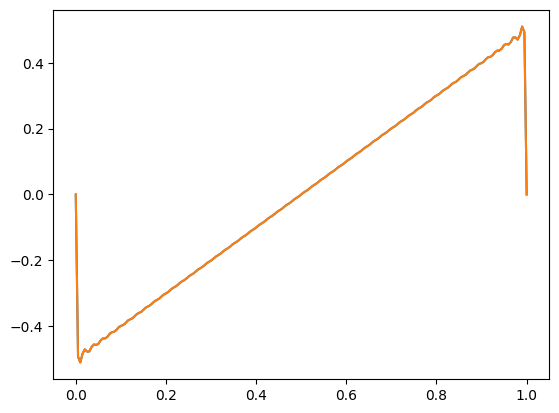

In [ ]:
# Borel resummed code - accelerated via convolution methods

import matplotlib.pyplot as plt
from functools import wraps
import numpy as np
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
import scipy.integrate as integrate
from scipy.optimize import minimize_scalar
from scipy.signal import fftconvolve
import scipy.special as ssp


# using Gunnar's two-mode baseline potential
def initialise_modes(A, L=1.0):  # base shape generator
  a_indices_full = np.arange(-A, A + 1)  # shifted array
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  # initial sawtooth potential as was in the paper
  nonzero = a_indices_full != 0
  U_base[nonzero] = 1j * L**2 / (2.0 * np.pi * a_indices_full[nonzero])

  # plot the potential graph
  x_vals = np.linspace(0, L, 200)
  U_vals = (
      np.sum(
          U_base[:, None]
          * np.exp(
              1j * 2 * np.pi * a_indices_full[:, None] * x_vals[None, :] / L
          ),
          axis=0,
      )
      / L
  )
  plt.plot(x_vals, np.real(U_vals), label="Re(U)")

  return a_indices_full, U_base


def U_modes(theta, U_base, A_k, a_indices_full):
  U_active = np.zeros_like(U_base, dtype=complex)
  index = {int(a): i for i, a in enumerate(a_indices_full)}
  for a in range(1, A_k + 1):
    i = index[a]
    j = index[-a]
    re = theta[2 * (a - 1)]
    im = theta[2 * (a - 1) + 1]
    U_active[i] = re + 1j * im
    U_active[j] = np.conjugate(U_active[i])
  return U_active


def check_borel_radius_of_convergence(coeffs, nu=1.0, min_coefficient=1e-14):
  coeffs = np.asarray(coeffs, dtype=float)
  n_vals = np.arange(len(coeffs))
  factorials = np.array(
      [ssp.factorial(n, exact=False) for n in n_vals], dtype=float
  )
  borel_coeffs = coeffs / factorials

  radii_current = []
  radii_derivative = []

  for n in range(3, len(borel_coeffs), 2):
    bc_prev = borel_coeffs[n - 2]
    bc_curr = borel_coeffs[n]
    if abs(bc_prev) > min_coefficient and abs(bc_curr) > min_coefficient:
      radii_current.append(np.sqrt(abs(bc_prev / bc_curr)))
      d_prev = (n - 2) * bc_prev
      d_curr = n * bc_curr
      radii_derivative.append(np.sqrt(abs(d_prev / d_curr)))

  if not radii_current:
    return {"borel_radius": 0.0, "valid_borel_behavior": False}

  borel_radius_used = min(
      min(radii_current),
      min(radii_derivative) if radii_derivative else min(radii_current),
  )
  valid_borel_behavior = np.isfinite(borel_radius_used) and (
      borel_radius_used > 1e-3
  )

  return {
      "borel_radius": float(borel_radius_used),
      "valid_borel_behavior": bool(valid_borel_behavior),
  }


def current_series_and_gradient(
    a_indices,
    U_modes,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
):
  N = len(a_indices)  # 2A+1
  k_vals = 2.0 * np.pi * a_indices / L
  P = 2 * A_k

  mode_index = {int(a): i for i, a in enumerate(a_indices)}

  # Fast convolution representation for W
  W_conv = k_vals * U_modes / L

  # construct mode-by-mode gradient helper
  def dU_dtheta(p, b):
    mode = p // 2 + 1
    is_real_part = p % 2 == 0
    if b == mode:
      return 1.0 if is_real_part else 1.0j
    if b == -mode:
      return 1.0 if is_real_part else -1.0j
    return 0.0

  # Construct dW_conv as a 2D matrix of shape (P, N) instead of 3D tensor
  dW_conv = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      dW_conv[p, i] = k_vals[i] * dU_dtheta(p, a) / L

  # calculate Fourier coefficients C_a, C^_a, C_a_
  C = np.zeros(N, dtype=complex)
  C_hat = np.zeros(N, dtype=complex)
  C_under = np.zeros(N, dtype=complex)

  for i, a in enumerate(a_indices):
    if a != 0:
      denom = (
          D**2 * k_vals[i] ** 4
          + w**2 * k_vals[i] ** 2
          + 2 * gamma * k_vals[i] ** 2 * D
      )
      C[i] = (D * k_vals[i] ** 2 + 2 * gamma) * k_vals[i] / denom
      C_hat[i] = 1j * w * k_vals[i] ** 2 / denom
      C_under[i] = D * k_vals[i] ** 2 * k_vals[i] / denom

  # Initialize order-0 fields
  rho = np.zeros(N, dtype=complex)
  m = np.zeros(N, dtype=complex)
  if 0 in a_indices:
    rho[mode_index[0]] = 1.0

  rho_s = np.zeros((P, N), dtype=complex)
  m_s = np.zeros((P, N), dtype=complex)

  # Construct current extraction vector (W_{-a})
  W_minus_a = np.zeros(N, dtype=complex)
  for i, a in enumerate(a_indices):
    minus_a = int(-a)
    if minus_a in mode_index:
      r = mode_index[minus_a]
      W_minus_a[i] = k_vals[r] * U_modes[r] / L

  dW_minus_all = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      minus_a = int(-a)
      if minus_a in mode_index:
        r = mode_index[minus_a]
        dW_minus_all[p, i] = k_vals[r] * dU_dtheta(p, minus_a) / L

  J_0 = 0.0
  J_1 = (-1j / L) * np.dot(W_minus_a, rho)
  coeffs = [J_0, J_1.real]

  grad_coeffs = [np.zeros(P, dtype=float)]
  grad_J_1 = np.zeros(P, dtype=float)
  for p in range(P):
    dJ_1 = (-1j / L) * np.dot(dW_minus_all[p], rho)
    grad_J_1[p] = dJ_1.real

  grad_coeffs.append(grad_J_1)

  # Convolution helper mapped to N-sized centered arrays
  def convolve_1d(a, b):
    full = np.convolve(a, b)
    mid = len(full) // 2
    start = mid - N // 2
    return full[start : start + N]

  def convolve_rows(matrix, vector):
    res = np.empty_like(matrix)
    for p in range(P):
      full = np.convolve(matrix[p], vector)
      mid = len(full) // 2
      start = mid - N // 2
      res[p] = full[start : start + N]
    return res

  for order in range(1, N_nu):
    sum_rho = convolve_1d(W_conv, rho)
    sum_m = convolve_1d(W_conv, m)

    rho_next = C_hat * sum_m - C * sum_rho
    m_next = C_hat * sum_rho - C_under * sum_m

    rho_s_next = np.zeros((P, N), dtype=complex)
    m_s_next = np.zeros((P, N), dtype=complex)

    dW_rho = convolve_rows(dW_conv, rho)
    W_rhos = convolve_rows(rho_s, W_conv)
    d_sum_rho = dW_rho + W_rhos

    dW_m = convolve_rows(dW_conv, m)
    W_ms = convolve_rows(m_s, W_conv)
    d_sum_m = dW_m + W_ms

    for p in range(P):
      rho_s_next[p] = C_hat * d_sum_m[p] - C * d_sum_rho[p]
      m_s_next[p] = C_hat * d_sum_rho[p] - C_under * d_sum_m[p]

    J_next = (-1j / L) * np.dot(W_minus_a, rho_next)
    coeffs.append(J_next.real)

    grad_J_next = np.zeros(P, dtype=float)
    for p in range(P):
      dJ_next = (-1j / L) * (
          np.dot(dW_minus_all[p], rho_next) + np.dot(W_minus_a, rho_s_next[p])
      )
      grad_J_next[p] = dJ_next.real
    grad_coeffs.append(grad_J_next)

    rho = rho_next
    m = m_next
    rho_s = rho_s_next
    m_s = m_s_next

  coeffs = np.asarray(coeffs, dtype=float)
  grad_coeffs = np.asarray(grad_coeffs, dtype=float)
  factorials = np.array([ssp.factorial(n) for n in range(len(coeffs))], dtype=float)
  borel_coeffs = coeffs / factorials
  borel_grad_coeffs = grad_coeffs / factorials[:, None]

  def laplace_integrand(z):
    return polyval(nu * z, borel_coeffs) * np.exp(-z)

  def laplace_integrand_grad(z):
    return (
        np.array([polyval(nu * z, borel_grad_coeffs[:, p]) for p in range(P)])
        * np.exp(-z)
    )

  J_total, err = integrate.quad(
      laplace_integrand, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total, grad_err = integrate.quad_vec(
      laplace_integrand_grad, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total = np.asarray(grad_J_total.real, dtype=float)

  if return_coeffs:
    return float(J_total), grad_J_total, coeffs.copy()

  return float(J_total), grad_J_total


# Now the rest of your original simulation setup, optimization loop, and plotting code remains identical:

A_max = 250
step = 50
L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0
N_nu_val = 75
nu_height = 1.0

def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-8,
    ftol=1e-10,
    initial_step=1.0,
    verbose=True,
):
  x = np.asarray(theta0, dtype=float).copy()
  J, grad, coeffs = J_and_grad(x)
  J = float(J)
  grad = np.asarray(grad, dtype=float)

  if not np.isfinite(J) or not np.all(np.isfinite(grad)):
    raise ValueError("Initial current or gradient is not finite.")

  direction = grad.copy()
  history = []
  stopped_reason = "max iterations reached"
  converged = False

  for iteration in range(1, max_iter + 1):
    grad_norm = float(np.linalg.norm(grad, ord=np.inf))
    history.append({
        "iteration": iteration,
        "J": J,
        "grad_norm": grad_norm,
    })

    if grad_norm < gtol:
      converged = True
      stopped_reason = "gradient tolerance"
      break

    slope = float(np.dot(grad, direction))
    if slope <= 0.0:
      direction = grad.copy()
      slope = float(np.dot(grad, grad))

    # Efficient backtracking line search with live Borel radius validation
    accepted = False
    step = min(initial_step, 0.2 / max(np.linalg.norm(direction), 1.0e-12))

    for _ in range(24):
      candidate = x + step * direction
      try:
        J_trial, grad_trial, coeffs_trial = J_and_grad(candidate)
        borel_check = check_borel_radius_of_convergence(
            coeffs_trial, nu=nu_height
        )
        valid = (
            np.isfinite(J_trial)
            and np.all(np.isfinite(grad_trial))
            and borel_check["valid_borel_behavior"]
        )

        # Armijo sufficient ascent condition + radius validity
        if valid and J_trial >= J + 1.0e-4 * step * slope:
          accepted = True
          break
      except Exception:
        pass
      step *= 0.5

    if not accepted:
      stopped_reason = "line search failed or left valid Borel domain"
      break

    new_grad = np.asarray(grad_trial, dtype=float)
    den = max(float(np.dot(grad, grad)), 1.0e-30)

    # Polak-Ribière beta with strict stable clamping [0, 1]
    beta = min(1.0, max(0.0, float(np.dot(new_grad, new_grad - grad)) / den))

    direction = new_grad + beta * direction
    x = candidate
    J = float(J_trial)
    grad = new_grad

    if verbose:
      print(
          f"frprmn iteration {iteration:3d}: J={J:.12e},"
          f" step={step:.4e}, beta={beta:.4e},"
          f" ||grad||inf={grad_norm:.4e}"
      )

  info = {
      "converged": converged,
      "stopped_reason": stopped_reason,
      "history": history,
      "gradient_norm": float(np.linalg.norm(grad, ord=np.inf)),
  }
  return x, J, info


def optimiser(
    A_max, step, L_domain, D_diff, w_freq, gamma_rtp, N_nu_val, nu_height
):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(A=A_cutoff, L=L_domain)

  n_stages = A_max // step
  theta_opt = None
  stage_results = []
  for k in range(n_stages):
    stage = k + 1
    A_k = (k + 1) * step
    dim_k = 2 * A_k

    theta_init = np.zeros(dim_k, dtype=float)
    if theta_opt is None:
      for a in range(1, A_k + 1):
        i = np.where(a_indices_full == a)[0][0]
        U_a = U_base[i]
        theta_init[2 * (a - 1)] = U_a.real
        theta_init[2 * (a - 1) + 1] = U_a.imag
    else:
      n_old = len(theta_opt)
      if n_old > dim_k:
        raise RuntimeError("Previous parameter vector is larger than current one")
      theta_init[:n_old] = theta_opt
      theta_init[n_old:] = 0.0

    def J_and_grad(theta_vec):
      U_modes_now = U_modes(theta_vec, U_base, A_k, a_indices_full)
      J, grad, coeffs = current_series_and_gradient(
          a_indices=a_indices_full,
          U_modes=U_modes_now,
          A_k=A_k,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height,
          return_coeffs=True
      )
      return J, grad, coeffs

    J_initial, grad_initial, coeffs = J_and_grad(theta_init)

    print(f"\nStarting stage {stage}/{n_stages}")
    print(f"A_k = {A_k}")
    print(f"Number of parameters = {dim_k}")
    print(f"Initial current = {J_initial:.12e}")
    print(
        "Initial gradient norm ="
        f" {np.linalg.norm(grad_initial, ord=np.inf):.6e}"
    )

    theta_candidate, J_candidate, info = frprmn_maximise(
        theta0=theta_init,
        J_and_grad=J_and_grad,
        max_iter=100,
        gtol=1e-8,
        ftol=1e-10,
        initial_step=1.0,
        verbose=True,
    )
    U_candidate = U_modes(theta_candidate, U_base, A_k, a_indices_full)

    J_candidate, grad_candidate, coeffs_candidate = current_series_and_gradient(
        a_indices=a_indices_full,
        U_modes=U_candidate,
        A_k=A_k,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height,
        return_coeffs=True,
    )

    borel_check = check_borel_radius_of_convergence(coeffs_candidate, nu=nu_height)

    radius_used = borel_check["borel_radius"]
    improves = J_candidate >= J_initial
    candidate_stable = (
        np.isfinite(J_candidate) and improves and borel_check["valid_borel_behavior"]
    )

    if candidate_stable:
      theta_opt = theta_candidate.copy()
      J_best = J_candidate
      accepted = True
      status = "accepted"
    else:
      print(
          "Rejecting candidate: "
          f"J={J_candidate:.6e}, radius={radius_used:.6e}, "
          f"|nu|={abs(nu_height):.6e}, "
          f"valid_borel={borel_check['valid_borel_behavior']}, "
          f"improves={improves}"
      )
      theta_opt = theta_init.copy()
      J_best = J_initial
      accepted = False
      status = "rejected: outside radius or no improvement"

    J_final, grad_final, _ = J_and_grad(theta_opt)
    result = {
        "stage": stage,
        "A_k": A_k,
        "theta_initial": theta_init.copy(),
        "theta_opt": theta_opt.copy(),
        "J_initial": J_initial,
        "J_best": J_best,
        "J_final": J_final,
        "gradient_norm": np.linalg.norm(grad_final, ord=np.inf),
        "frprmn_info": info,
        "borel_radius": radius_used,
        "valid_borel_behavior": borel_check["valid_borel_behavior"],
        "accepted": accepted,
        "status": status,
    }

    stage_results.append(result)

    print(
        f"Finished stage {stage}: A_k={A_k}, J_initial={J_initial:.12e},"
        f" J_final={J_final:.12e},"
        f" iterations={info['iteration'] if 'iteration' in info else 'N/A'},"
        f" reason={info['stopped_reason']}, radius={radius_used:.6e},"
        f" valid_borel={borel_check['valid_borel_behavior']}, status={status}"
    )

  return theta_opt, a_indices_full, U_base, stage_results


a_indices_full, U_base = initialise_modes(A_max, L_domain)
J, grad_J, coeffs = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_base,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_coeffs=True
)

print("J =", J)
print("gradient shape =", grad_J.shape)
print("gradient =", grad_J)

theta_opt, a_indices_full, U_base, stage_results = optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
)
# ============================================================
# Compact results report and plots
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Compact stage-results table
# ------------------------------------------------------------

table_rows = []

for result in stage_results:

    info = result["frprmn_info"]

    table_rows.append({
        "stage": result["stage"],
        "A": result["A_k"],
        "J_initial": result["J_initial"],
        "J_final": result["J_final"],
        "improvement": (
            result["J_final"]
            - result["J_initial"]
        ),
        "gradient_inf": result["gradient_norm"],
        "iterations": len(
            info["history"]
        ) - 1,
        "status": info["stopped_reason"]
    })

results_table = pd.DataFrame(
    table_rows
)

print("\n===== Modal continuation results =====\n")

print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format
        }
    )
)


# ------------------------------------------------------------
# 2. Reconstruct final optimised potential
# ------------------------------------------------------------

U_opt = U_modes(
    theta_opt,
    U_base,
    A_max,
    a_indices_full
)

x_plot = np.linspace(
    0.0,
    L_domain,
    2000,
    endpoint=False
)

k_vals = (
    2.0
    * np.pi
    * a_indices_full
    / L_domain
)

U_opt_x = np.sum(
    U_opt[:, None]
    * np.exp(
        1j
        * k_vals[:, None]
        * x_plot[None, :]
    ),
    axis=0
) / L_domain


# ------------------------------------------------------------
# 3. Extract final-stage optimisation history
# ------------------------------------------------------------

final_info = stage_results[-1]["frprmn_info"]
history = pd.DataFrame(
    final_info["history"]
)


# ------------------------------------------------------------
# 4. Three-panel summary figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)


# Panel 1: current against number of modes
axes[0].plot(
    results_table["A"],
    results_table["J_initial"],
    "o--",
    label="Embedded initial"
)

axes[0].plot(
    results_table["A"],
    results_table["J_final"],
    "s-",
    label="Final"
)

axes[0].set_xlabel("Maximum active mode A")
axes[0].set_ylabel("Current J")
axes[0].set_title("Modal continuation")
axes[0].grid(alpha=0.3)
axes[0].legend()


# Panel 2: final potential
axes[1].plot(
    x_plot / L_domain,
    U_opt_x.real,
    linewidth=2.0
)

axes[1].set_xlabel(r"$x/L$")
axes[1].set_ylabel(r"$U(x)$")
axes[1].set_title(
    f"Final potential, A={A_max}"
)
axes[1].grid(alpha=0.3)


# Panel 3: final optimisation history
axes[2].plot(
    history["iteration"],
    history["J"],
    "o-",
    label="J"
)

axes[2].set_xlabel("frprmn iteration")
axes[2].set_ylabel("Current J")
axes[2].set_title("Optimisation history")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Gradient-norm history
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.semilogy(
    history["iteration"],
    history["grad_norm"],
    "o-"
)

plt.xlabel("frprmn iteration")
plt.ylabel(r"$\|\nabla J\|_\infty$")
plt.title(
    f"Gradient history, A={A_max}"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Optional perturbative-order diagnostic
# ------------------------------------------------------------

orders = [3, 5, 7, 9, 11, 13]

order_currents = []

for N_test in orders:

    J_test, grad_test = (
        current_series_and_gradient(
            a_indices=a_indices_full,
            U_modes=U_opt,
            A_k=A_max,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_test,
            nu=nu_height
        )
    )

    order_currents.append(J_test)

order_table = pd.DataFrame({
    "N_nu": orders,
    "J": order_currents
})

print("\n===== Perturbative-order diagnostic =====\n")

print(
    order_table.to_string(
        index=False,
        formatters={
            "J": "{:.8e}".format
        }
    )
)
# ------------------------------------------------------------
# Plot A_max versus optimised current
# ------------------------------------------------------------

A_values = np.array([
    result["A_k"]
    for result in stage_results
])

J_values = np.array([
    result["J_final"]
    for result in stage_results
])

plt.figure(figsize=(7, 4))

plt.plot(
    A_values,
    J_values,
    "o-",
    linewidth=2,
    markersize=6
)

plt.xlabel(r"Active Fourier cutoff $A$")
plt.ylabel(r"Optimised current $J$")
plt.title("Optimised current versus number of modes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

J = 0.0022142785322350517
gradient shape = (500,)
gradient = [-1.90777531e+00 -2.96701039e-01 -1.97820853e+00 -1.48035946e-01
 -1.99271087e+00 -9.65735156e-02 -1.99792560e+00 -7.02288538e-02
 -2.00037908e+00 -5.39324553e-02 -2.00173557e+00 -4.26524384e-02
 -2.00257322e+00 -3.42342173e-02 -2.00313515e+00 -2.76014563e-02
 -2.00353795e+00 -2.21565841e-02 -2.00384311e+00 -1.75412216e-02
 -2.00408554e+00 -1.35273790e-02 -2.00428620e+00 -9.96309079e-03
 -2.00445831e+00 -6.74315903e-03 -2.00461049e+00 -3.79244186e-03
 -2.00474858e+00 -1.05583013e-03 -2.00487662e+00  1.50801546e-03
 -2.00499748e+00  3.93071597e-03 -2.00511323e+00  6.23687471e-03
 -2.00522540e+00  8.44592477e-03 -2.00533512e+00  1.05734221e-02
 -2.00544326e+00  1.26319688e-02 -2.00555047e+00  1.46318852e-02
 -2.00565726e+00  1.65817057e-02 -2.00576401e+00  1.84885514e-02
 -2.00587103e+00  2.03584126e-02 -2.00597857e+00  2.21963669e-02
 -2.00608679e+00  2.40067480e-02 -2.00619586e+00  2.57932789e-02
 -2.00630589e+00  2.75591774e

KeyboardInterrupt: 

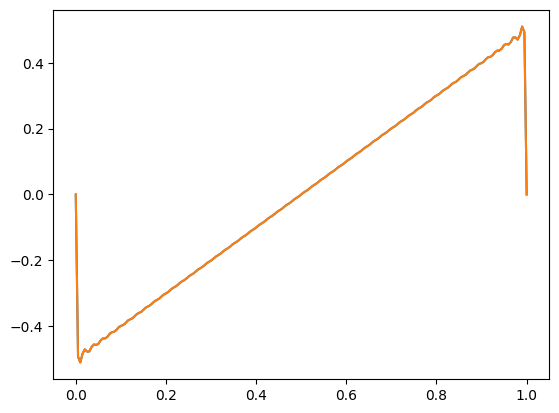

In [ ]:
# Borel resummed code - accelerated via convolution methods & core recurrence

import matplotlib.pyplot as plt
from functools import wraps
import numpy as np
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
import scipy.integrate as integrate
from scipy.optimize import minimize_scalar
from scipy.signal import fftconvolve
import scipy.special as ssp


# using Gunnar's two-mode baseline potential
def initialise_modes(A, L=1.0):  # base shape generator
  a_indices_full = np.arange(-A, A + 1)  # shifted array
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  # initial sawtooth potential as was in the paper
  nonzero = a_indices_full != 0
  U_base[nonzero] = 1j * L**2 / (2.0 * np.pi * a_indices_full[nonzero])

  # plot the potential graph
  x_vals = np.linspace(0, L, 200)
  U_vals = (
      np.sum(
          U_base[:, None]
          * np.exp(
              1j * 2 * np.pi * a_indices_full[:, None] * x_vals[None, :] / L
          ),
          axis=0,
      )
      / L
  )
  plt.plot(x_vals, np.real(U_vals), label="Re(U)")

  return a_indices_full, U_base


def U_modes(theta, U_base, A_k, a_indices_full):
  U_active = np.zeros_like(U_base, dtype=complex)
  index = {int(a): i for i, a in enumerate(a_indices_full)}
  for a in range(1, A_k + 1):
    i = index[a]
    j = index[-a]
    re = theta[2 * (a - 1)]
    im = theta[2 * (a - 1) + 1]
    U_active[i] = re + 1j * im
    U_active[j] = np.conjugate(U_active[i])
  return U_active


def check_borel_radius_of_convergence(coeffs, nu=1.0, min_coefficient=1e-14):
  coeffs = np.asarray(coeffs, dtype=float)
  n_vals = np.arange(len(coeffs))
  factorials = np.array(
      [ssp.factorial(n, exact=False) for n in n_vals], dtype=float
  )
  borel_coeffs = coeffs / factorials

  radii_current = []
  radii_derivative = []

  for n in range(3, len(borel_coeffs), 2):
    bc_prev = borel_coeffs[n - 2]
    bc_curr = borel_coeffs[n]
    if abs(bc_prev) > min_coefficient and abs(bc_curr) > min_coefficient:
      radii_current.append(np.sqrt(abs(bc_prev / bc_curr)))
      d_prev = (n - 2) * bc_prev
      d_curr = n * bc_curr
      radii_derivative.append(np.sqrt(abs(d_prev / d_curr)))

  if not radii_current:
    return {"borel_radius": 0.0, "valid_borel_behavior": False}

  borel_radius_used = min(
      min(radii_current),
      min(radii_derivative) if radii_derivative else min(radii_current),
  )
  valid_borel_behavior = np.isfinite(borel_radius_used) and (
      borel_radius_used > 1e-3
  )

  return {
      "borel_radius": float(borel_radius_used),
      "valid_borel_behavior": bool(valid_borel_behavior),
  }


# Core convolution and chunked derivative recurrence steps from zigan_colab_core.py
def _convolve_rows(left: np.ndarray, right: np.ndarray) -> np.ndarray:
  return fftconvolve(left, right, mode="full", axes=1)


def _derivative_recurrence_step(
    rho, mom, drho, dmom, W, dW, c_hat, c_none, c_und, chunk_size=16
):
  P = drho.shape[0]
  output_length = drho.shape[1] + len(W) - 1
  new_drho = np.empty((P, output_length), dtype=np.complex128)
  new_dmom = np.empty((P, output_length), dtype=np.complex128)

  for start in range(0, P, chunk_size):
    stop = min(start + chunk_size, P)
    sl = slice(start, stop)
    drho_w = _convolve_rows(drho[sl], W[None, :]) + _convolve_rows(
        rho[None, :], dW[sl]
    )
    dmom_w = _convolve_rows(dmom[sl], W[None, :]) + _convolve_rows(
        mom[None, :], dW[sl]
    )
    new_drho[sl] = c_hat[None, :] * dmom_w - c_none[None, :] * drho_w
    new_dmom[sl] = c_hat[None, :] * drho_w - c_und[None, :] * dmom_w
  return new_drho, new_dmom


def current_series_and_gradient(
    a_indices,
    U_modes,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
):
  A = A_k
  P = 2 * A_k

  # Slice U_modes to the active window for the current stage A_k
  center = len(a_indices) // 2
  U_modes = U_modes[center - A : center + A + 1]

  potential_modes = np.arange(-A, A + 1)
  k_potential = 2.0 * np.pi * potential_modes / L

  W = k_potential * U_modes / L

  def dU_dtheta(p, b):
    mode = p // 2 + 1
    is_real_part = p % 2 == 0
    if b == mode:
      return 1.0 if is_real_part else 1.0j
    if b == -mode:
      return 1.0 if is_real_part else -1.0j
    return 0.0

  dW = np.zeros((P, len(potential_modes)), dtype=complex)
  for p in range(P):
    for idx, a in enumerate(potential_modes):
      dW[p, idx] = k_potential[idx] * dU_dtheta(p, a) / L

  rho = np.array([1.0 + 0.0j])
  mom = np.array([0.0 + 0.0j])
  drho = np.zeros((P, 1), dtype=np.complex128)
  dmom = np.zeros((P, 1), dtype=np.complex128)

  coeffs = np.zeros(N_nu + 1, dtype=np.complex128)
  dterms = np.zeros((N_nu + 1, P), dtype=np.complex128)

  for recurrence_order in range(1, N_nu):
    support = recurrence_order * A
    mode_indices = np.arange(-support, support + 1)
    k = 2.0 * np.pi * mode_indices / L
    denominator = D * D * k * k + w * w + 2.0 * gamma * D

    c_hat = np.zeros_like(k, dtype=np.complex128)
    c_none = np.zeros_like(k)
    c_und = np.zeros_like(k)
    nonzero = mode_indices != 0
    c_hat[nonzero] = 1j * w / denominator[nonzero]
    c_none[nonzero] = (D * k[nonzero] ** 2 + 2.0 * gamma) / (
        k[nonzero] * denominator[nonzero]
    )
    c_und[nonzero] = D * k[nonzero] / denominator[nonzero]

    rho_w = np.convolve(rho, W)
    mom_w = np.convolve(mom, W)
    new_rho = c_hat * mom_w - c_none * rho_w
    new_mom = c_hat * rho_w - c_und * mom_w
    new_drho, new_dmom = _derivative_recurrence_step(
        rho, mom, drho, dmom, W, dW, c_hat, c_none, c_und
    )
    rho, mom = new_rho, new_mom
    drho, dmom = new_drho, new_dmom

    current_order = recurrence_order + 1
    offset = support
    rho_slice = rho[offset - A : offset + A + 1]
    drho_slice = drho[:, offset - A : offset + A + 1]
    U_minus = U_modes[::-1]
    dW_minus = dW[:, ::-1]
    prefactor = 1j * k_potential

    coeffs[current_order] = np.sum(prefactor * U_minus * rho_slice) / (L * L)
    dterms[current_order] = np.sum(
        prefactor[None, :]
        * (dW_minus * rho_slice[None, :] + U_minus[None, :] * drho_slice),
        axis=1,
    ).real / (L * L)

  coeffs_val = coeffs.real
  grad_coeffs = dterms

  factorials = np.array([ssp.factorial(n, exact=False) for n in range(len(coeffs_val))], dtype=float)
  borel_coeffs = coeffs_val / factorials
  borel_grad_coeffs = grad_coeffs / factorials[:, None]

  def laplace_integrand(z):
    return polyval(nu * z, borel_coeffs) * np.exp(-z)

  def laplace_integrand_grad(z):
    return (
        np.array([polyval(nu * z, borel_grad_coeffs[:, p]) for p in range(P)])
        * np.exp(-z)
    )

  J_total, err = integrate.quad(
      laplace_integrand, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total, grad_err = integrate.quad_vec(
      laplace_integrand_grad, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total = np.asarray(grad_J_total.real, dtype=float)

  if return_coeffs:
    return float(J_total), grad_J_total, coeffs_val.copy()

  return float(J_total), grad_J_total


# Now the rest of your original simulation setup, optimization loop, and plotting code remains identical:

A_max = 250
step = 50
L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0
N_nu_val = 75
nu_height = 1.0

def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-8,
    ftol=1e-10,
    initial_step=1.0,
    verbose=True,
):
  x = np.asarray(theta0, dtype=float).copy()
  J, grad, coeffs = J_and_grad(x)
  J = float(J)
  grad = np.asarray(grad, dtype=float)

  if not np.isfinite(J) or not np.all(np.isfinite(grad)):
    raise ValueError("Initial current or gradient is not finite.")

  direction = grad.copy()
  history = []
  stopped_reason = "max iterations reached"
  converged = False

  for iteration in range(1, max_iter + 1):
    grad_norm = float(np.linalg.norm(grad, ord=np.inf))
    history.append({
        "iteration": iteration,
        "J": J,
        "grad_norm": grad_norm,
    })

    if grad_norm < gtol:
      converged = True
      stopped_reason = "gradient tolerance"
      break

    slope = float(np.dot(grad, direction))
    if slope <= 0.0:
      direction = grad.copy()
      slope = float(np.dot(grad, grad))

    # Efficient backtracking line search with live Borel radius validation
    accepted = False
    step_val = min(initial_step, 0.2 / max(np.linalg.norm(direction), 1.0e-12))

    for _ in range(24):
      candidate = x + step_val * direction
      try:
        J_trial, grad_trial, coeffs_trial = J_and_grad(candidate)
        borel_check = check_borel_radius_of_convergence(
            coeffs_trial, nu=nu_height
        )
        valid = (
            np.isfinite(J_trial)
            and np.all(np.isfinite(grad_trial))
            and borel_check["valid_borel_behavior"]
        )

        # Armijo sufficient ascent condition + radius validity
        if valid and J_trial >= J + 1.0e-4 * step_val * slope:
          accepted = True
          break
      except Exception:
        pass
      step_val *= 0.5

    if not accepted:
      stopped_reason = "line search failed or left valid Borel domain"
      break

    new_grad = np.asarray(grad_trial, dtype=float)
    den = max(float(np.dot(grad, grad)), 1.0e-30)

    # Polak-Ribière beta with strict stable clamping [0, 1]
    beta = min(1.0, max(0.0, float(np.dot(new_grad, new_grad - grad)) / den))

    direction = new_grad + beta * direction
    x = candidate
    J = float(J_trial)
    grad = new_grad

    if verbose:
      print(
          f"frprmn iteration {iteration:3d}: J={J:.12e},"
          f" step={step_val:.4e}, beta={beta:.4e},"
          f" ||grad||inf={grad_norm:.4e}"
      )

  info = {
      "converged": converged,
      "stopped_reason": stopped_reason,
      "history": history,
      "gradient_norm": float(np.linalg.norm(grad, ord=np.inf)),
  }
  return x, J, info


def optimiser(
    A_max, step, L_domain, D_diff, w_freq, gamma_rtp, N_nu_val, nu_height
):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(A=A_cutoff, L=L_domain)

  n_stages = A_max // step
  theta_opt = None
  stage_results = []
  for k in range(n_stages):
    stage = k + 1
    A_k = (k + 1) * step
    dim_k = 2 * A_k

    theta_init = np.zeros(dim_k, dtype=float)
    if theta_opt is None:
      for a in range(1, A_k + 1):
        i = np.where(a_indices_full == a)[0][0]
        U_a = U_base[i]
        theta_init[2 * (a - 1)] = U_a.real
        theta_init[2 * (a - 1) + 1] = U_a.imag
    else:
      n_old = len(theta_opt)
      if n_old > dim_k:
        raise RuntimeError("Previous parameter vector is larger than current one")
      theta_init[:n_old] = theta_opt
      theta_init[n_old:] = 0.0

    def J_and_grad(theta_vec):
      U_modes_now = U_modes(theta_vec, U_base, A_k, a_indices_full)
      J, grad, coeffs = current_series_and_gradient(
          a_indices=a_indices_full,
          U_modes=U_modes_now,
          A_k=A_k,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height,
          return_coeffs=True
      )
      return J, grad, coeffs

    J_initial, grad_initial, coeffs = J_and_grad(theta_init)

    print(f"\nStarting stage {stage}/{n_stages}")
    print(f"A_k = {A_k}")
    print(f"Number of parameters = {dim_k}")
    print(f"Initial current = {J_initial:.12e}")
    print(
        "Initial gradient norm ="
        f" {np.linalg.norm(grad_initial, ord=np.inf):.6e}"
    )

    theta_candidate, J_candidate, info = frprmn_maximise(
        theta0=theta_init,
        J_and_grad=J_and_grad,
        max_iter=100,
        gtol=1e-8,
        ftol=1e-10,
        initial_step=1.0,
        verbose=True,
    )
    U_candidate = U_modes(theta_candidate, U_base, A_k, a_indices_full)

    J_candidate, grad_candidate, coeffs_candidate = current_series_and_gradient(
        a_indices=a_indices_full,
        U_modes=U_candidate,
        A_k=A_k,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height,
        return_coeffs=True,
    )

    borel_check = check_borel_radius_of_convergence(coeffs_candidate, nu=nu_height)

    radius_used = borel_check["borel_radius"]
    improves = J_candidate >= J_initial
    candidate_stable = (
        np.isfinite(J_candidate) and improves and borel_check["valid_borel_behavior"]
    )

    if candidate_stable:
      theta_opt = theta_candidate.copy()
      J_best = J_candidate
      accepted = True
      status = "accepted"
    else:
      print(
          "Rejecting candidate: "
          f"J={J_candidate:.6e}, radius={radius_used:.6e}, "
          f"|nu|={abs(nu_height):.6e}, "
          f"valid_borel={borel_check['valid_borel_behavior']}, "
          f"improves={improves}"
      )
      theta_opt = theta_init.copy()
      J_best = J_initial
      accepted = False
      status = "rejected: outside radius or no improvement"

    J_final, grad_final, _ = J_and_grad(theta_opt)
    result = {
        "stage": stage,
        "A_k": A_k,
        "theta_initial": theta_init.copy(),
        "theta_opt": theta_opt.copy(),
        "J_initial": J_initial,
        "J_best": J_best,
        "J_final": J_final,
        "gradient_norm": np.linalg.norm(grad_final, ord=np.inf),
        "frprmn_info": info,
        "borel_radius": radius_used,
        "valid_borel_behavior": borel_check["valid_borel_behavior"],
        "accepted": accepted,
        "status": status,
    }

    stage_results.append(result)

    print(
        f"Finished stage {stage}: A_k={A_k}, J_initial={J_initial:.12e},"
        f" J_final={J_final:.12e},"
        f" iterations={info['history'][-1]['iteration'] if 'history' in info and info['history'] else 'N/A'},"
        f" reason={info['stopped_reason']}, radius={radius_used:.6e},"
        f" valid_borel={borel_check['valid_borel_behavior']}, status={status}"
    )

  return theta_opt, a_indices_full, U_base, stage_results


a_indices_full, U_base = initialise_modes(A_max, L_domain)
J, grad_J, coeffs = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_base,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_coeffs=True
)

print("J =", J)
print("gradient shape =", grad_J.shape)
print("gradient =", grad_J)

theta_opt, a_indices_full, U_base, stage_results = optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
)

# ============================================================
# Compact results report and plots
# ============================================================

import pandas as pd

table_rows = []

for result in stage_results:
    info = result["frprmn_info"]
    table_rows.append({
        "stage": result["stage"],
        "A": result["A_k"],
        "J_initial": result["J_initial"],
        "J_final": result["J_final"],
        "improvement": (
            result["J_final"]
            - result["J_initial"]
        ),
        "gradient_inf": result["gradient_norm"],
        "iterations": len(info["history"]) - 1 if len(info["history"]) > 0 else 0,
        "status": info["stopped_reason"]
    })

results_table = pd.DataFrame(table_rows)

print("\n===== Modal continuation results =====\n")
print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format
        }
    )
)

U_opt = U_modes(
    theta_opt,
    U_base,
    A_max,
    a_indices_full
)

x_plot = np.linspace(
    0.0,
    L_domain,
    2000,
    endpoint=False
)

k_vals = (
    2.0
    * np.pi
    * a_indices_full
    / L_domain
)

U_opt_x = np.sum(
    U_opt[:, None]
    * np.exp(
        1j
        * k_vals[:, None]
        * x_plot[None, :]
    ),
    axis=0
) / L_domain

final_info = stage_results[-1]["frprmn_info"]
history = pd.DataFrame(
    final_info["history"]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

axes[0].plot(
    results_table["A"],
    results_table["J_initial"],
    "o--",
    label="Embedded initial"
)
axes[0].plot(
    results_table["A"],
    results_table["J_final"],
    "s-",
    label="Final"
)
axes[0].set_xlabel("Maximum active mode A")
axes[0].set_ylabel("Current J")
axes[0].set_title("Modal continuation")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    x_plot / L_domain,
    U_opt_x.real,
    linewidth=2.0
)
axes[1].set_xlabel(r"$x/L$")
axes[1].set_ylabel(r"$U(x)$")
axes[1].set_title(
    f"Final potential, A={A_max}"
)
axes[1].grid(alpha=0.3)

axes[2].plot(
    history["iteration"],
    history["J"],
    "o-",
    label="J"
)
axes[2].set_xlabel("frprmn iteration")
axes[2].set_ylabel("Current J")
axes[2].set_title("Optimisation history")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(
    history["iteration"],
    history["grad_norm"],
    "o-"
)
plt.xlabel("frprmn iteration")
plt.ylabel(r"$\|\nabla J\|_\infty$")
plt.title(
    f"Gradient history, A={A_max}"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

orders = [3, 5, 7, 9, 11, 13]
order_currents = []

for N_test in orders:
    J_test, grad_test = (
        current_series_and_gradient(
            a_indices=a_indices_full,
            U_modes=U_opt,
            A_k=A_max,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_test,
            nu=nu_height
        )
    )
    order_currents.append(J_test)

order_table = pd.DataFrame({
    "N_nu": orders,
    "J": order_currents
})

print("\n===== Perturbative-order diagnostic =====\n")
print(
    order_table.to_string(
        index=False,
        formatters={
            "J": "{:.8e}".format
        }
    )
)

A_values = np.array([
    result["A_k"]
    for result in stage_results
])

J_values = np.array([
    result["J_final"]
    for result in stage_results
])

plt.figure(figsize=(7, 4))
plt.plot(
    A_values,
    J_values,
    "o-",
    linewidth=2,
    markersize=6
)
plt.xlabel(r"Active Fourier cutoff $A$")
plt.ylabel(r"Optimised current $J$")
plt.title("Optimised current versus number of modes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

J = -0.0013655945857202565
gradient shape = (500,)
gradient = [-6.04971949e-17  1.36156965e-02 -8.86319457e-18  1.36707341e-02
 -6.91856926e-17  7.96752273e-03  4.21355824e-17  3.82543240e-03
 -3.37928040e-17  7.84855877e-04 -1.38903521e-17 -1.57552192e-03
 -6.08170344e-17 -3.49578471e-03  4.39381360e-17 -5.11458753e-03
 -4.34972468e-17 -6.51642044e-03 -7.54591643e-17 -7.75557492e-03
 -3.40425612e-17 -8.86859280e-03  4.50154562e-17 -9.88105883e-03
  2.22375079e-17 -1.08114964e-02 -7.73854816e-18 -1.16737055e-02
  1.62531470e-17 -1.24782226e-02 -2.02629497e-19 -1.32332658e-02
 -2.44308052e-17 -1.39453646e-02 -9.04872288e-18 -1.46197926e-02
 -4.24910354e-17 -1.52608701e-02 -1.56729598e-17 -1.58721828e-02
  4.91488751e-17 -1.64567403e-02 -1.55073988e-17 -1.70170947e-02
 -2.50727439e-17 -1.75554307e-02 -1.29391159e-17 -1.80736336e-02
  3.38477921e-17 -1.85733432e-02  2.76537620e-17 -1.90559954e-02
  3.97968782e-17 -1.95228557e-02 -3.18593144e-17 -1.99750458e-02
  5.28213149e-17 -2.04135653

/usr/local/lib/python3.12/dist-packages/numpy/polynomial/polynomial.py:764: RuntimeWarning: overflow encountered in scalar multiply
  c0 = c[-i] + c0*x
/tmp/ipykernel_1038/234665593.py:243: RuntimeWarning: invalid value encountered in scalar multiply
  return polyval(nu * z, borel_coeffs) * np.exp(-z)
/tmp/ipykernel_1038/234665593.py:251: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  J_total, err = integrate.quad(
/tmp/ipykernel_1038/234665593.py:247: RuntimeWarning: invalid value encountered in multiply
  np.array([polyval(nu * z, borel_grad_coeffs[:, p]) for p in range(P)])


ValueError: Bracketing values (xa, xb, xc) do not fulfill this requirement: (f(xb) < f(xa)) and (f(xb) < f(xc))

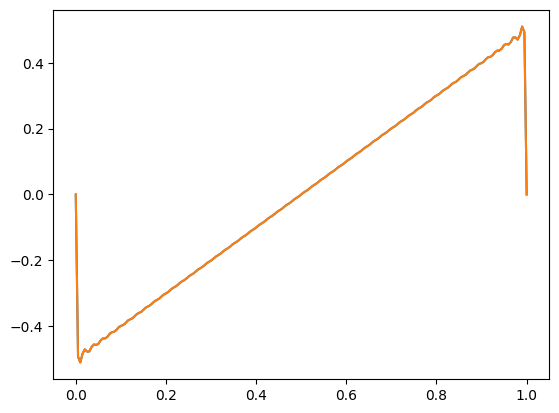

In [ ]:
# Borel resummed code - high-speed fixed-grid convolution engine

import matplotlib.pyplot as plt
from functools import wraps
import numpy as np
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
import scipy.integrate as integrate
from scipy.optimize import minimize_scalar
import scipy.special as ssp


# Using Gunnar's two-mode baseline potential
def initialise_modes(A, L=1.0):
  a_indices_full = np.arange(-A, A + 1)
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  nonzero = a_indices_full != 0
  U_base[nonzero] = 1j * L**2 / (2.0 * np.pi * a_indices_full[nonzero])

  x_vals = np.linspace(0, L, 200)
  U_vals = (
      np.sum(
          U_base[:, None]
          * np.exp(
              1j * 2 * np.pi * a_indices_full[:, None] * x_vals[None, :] / L
          ),
          axis=0,
      )
      / L
  )
  plt.plot(x_vals, np.real(U_vals), label="Re(U)")

  return a_indices_full, U_base


def U_modes(theta, U_base, A_k, a_indices_full):
  U_active = np.zeros_like(U_base, dtype=complex)
  index = {int(a): i for i, a in enumerate(a_indices_full)}
  for a in range(1, A_k + 1):
    i = index[a]
    j = index[-a]
    re = theta[2 * (a - 1)]
    im = theta[2 * (a - 1) + 1]
    U_active[i] = re + 1j * im
    U_active[j] = np.conjugate(U_active[i])
  return U_active


def check_radius_of_convergence(coeffs, nu=1.0, min_coefficient=1e-14):
  coeffs = np.asarray(coeffs, dtype=float)

  radii_current = []
  radii_derivative = []

  for n in range(3, len(coeffs), 2):
    c_previous = coeffs[n - 2]
    c_current = coeffs[n]

    if abs(c_previous) > min_coefficient and abs(c_current) > min_coefficient:
      radius_current = np.sqrt(abs(c_previous / c_current))
      radii_current.append(radius_current)

      d_previous = (n - 2) * c_previous
      d_current = n * c_current

      radius_derivative = np.sqrt(abs(d_previous / d_current))
      radii_derivative.append(radius_derivative)

  if len(radii_current) == 0:
    return {
        "radius_current": np.inf,
        "radius_derivative": np.inf,
        "inside_radius": False,
        "radii_current": [],
        "radii_derivative": [],
    }

  radius_current = min(radii_current)

  if len(radii_derivative) > 0:
    radius_derivative = min(radii_derivative)
  else:
    radius_derivative = radius_current

  radius_used = min(radius_current, radius_derivative)
  inside_radius = abs(nu) < radius_used

  return {
      "radius_current": radius_current,
      "radius_derivative": radius_derivative,
      "radius_used": radius_used,
      "inside_radius": inside_radius,
      "radii_current": np.asarray(radii_current),
      "radii_derivative": np.asarray(radii_derivative),
  }


def current_series_and_gradient(
    a_indices,
    U_modes,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
):
  N = len(a_indices)
  k_vals = 2.0 * np.pi * a_indices / L
  P = 2 * A_k

  mode_index = {int(a): i for i, a in enumerate(a_indices)}

  W_conv = k_vals * U_modes / L

  def dU_dtheta(p, b):
    mode = p // 2 + 1
    is_real_part = p % 2 == 0
    if b == mode:
      return 1.0 if is_real_part else 1.0j
    if b == -mode:
      return 1.0 if is_real_part else -1.0j
    return 0.0

  dW_conv = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      dW_conv[p, i] = k_vals[i] * dU_dtheta(p, a) / L

  C = np.zeros(N, dtype=complex)
  C_hat = np.zeros(N, dtype=complex)
  C_under = np.zeros(N, dtype=complex)

  for i, a in enumerate(a_indices):
    if a != 0:
      denom = (
          D**2 * k_vals[i] ** 4
          + w**2 * k_vals[i] ** 2
          + 2 * gamma * k_vals[i] ** 2 * D
      )
      C[i] = (D * k_vals[i] ** 2 + 2 * gamma) * k_vals[i] / denom
      C_hat[i] = 1j * w * k_vals[i] ** 2 / denom
      C_under[i] = D * k_vals[i] ** 2 * k_vals[i] / denom

  rho = np.zeros(N, dtype=complex)
  m = np.zeros(N, dtype=complex)
  if 0 in a_indices:
    rho[mode_index[0]] = 1.0

  rho_s = np.zeros((P, N), dtype=complex)
  m_s = np.zeros((P, N), dtype=complex)

  W_minus_a = np.zeros(N, dtype=complex)
  for i, a in enumerate(a_indices):
    minus_a = int(-a)
    if minus_a in mode_index:
      r = mode_index[minus_a]
      W_minus_a[i] = k_vals[r] * U_modes[r] / L

  dW_minus_all = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      minus_a = int(-a)
      if minus_a in mode_index:
        r = mode_index[minus_a]
        dW_minus_all[p, i] = k_vals[r] * dU_dtheta(p, minus_a) / L

  J_0 = 0.0
  J_1 = (-1j / L) * np.dot(W_minus_a, rho)
  coeffs = [J_0, J_1.real]

  grad_coeffs = [np.zeros(P, dtype=float)]
  grad_J_1 = np.zeros(P, dtype=float)
  for p in range(P):
    dJ_1 = (-1j / L) * np.dot(dW_minus_all[p], rho)
    grad_J_1[p] = dJ_1.real

  grad_coeffs.append(grad_J_1)

  def convolve_1d(a, b):
    full = np.convolve(a, b)
    mid = len(full) // 2
    start = mid - N // 2
    return full[start : start + N]

  def convolve_rows(matrix, vector):
    res = np.empty_like(matrix)
    for p in range(P):
      full = np.convolve(matrix[p], vector)
      mid = len(full) // 2
      start = mid - N // 2
      res[p] = full[start : start + N]
    return res

  for order in range(1, N_nu):
    sum_rho = convolve_1d(W_conv, rho)
    sum_m = convolve_1d(W_conv, m)

    rho_next = C_hat * sum_m - C * sum_rho
    m_next = C_hat * sum_rho - C_under * sum_m

    rho_s_next = np.zeros((P, N), dtype=complex)
    m_s_next = np.zeros((P, N), dtype=complex)

    dW_rho = convolve_rows(dW_conv, rho)
    W_rhos = convolve_rows(rho_s, W_conv)
    d_sum_rho = dW_rho + W_rhos

    dW_m = convolve_rows(dW_conv, m)
    W_ms = convolve_rows(m_s, W_conv)
    d_sum_m = dW_m + W_ms

    for p in range(P):
      rho_s_next[p] = C_hat * d_sum_m[p] - C * d_sum_rho[p]
      m_s_next[p] = C_hat * d_sum_rho[p] - C_under * d_sum_m[p]

    J_next = (-1j / L) * np.dot(W_minus_a, rho_next)
    coeffs.append(J_next.real)

    grad_J_next = np.zeros(P, dtype=float)
    for p in range(P):
      dJ_next = (-1j / L) * (
          np.dot(dW_minus_all[p], rho_next) + np.dot(W_minus_a, rho_s_next[p])
      )
      grad_J_next[p] = dJ_next.real
    grad_coeffs.append(grad_J_next)

    rho = rho_next
    m = m_next
    rho_s = rho_s_next
    m_s = m_s_next

  coeffs = np.asarray(coeffs, dtype=float)
  grad_coeffs = np.asarray(grad_coeffs, dtype=float)
  factorials = np.array([ssp.factorial(n) for n in range(len(coeffs))], dtype=float)
  borel_coeffs = coeffs / factorials
  borel_grad_coeffs = grad_coeffs / factorials[:, None]

  def laplace_integrand(z):
    return polyval(nu * z, borel_coeffs) * np.exp(-z)

  def laplace_integrand_grad(z):
    return (
        np.array([polyval(nu * z, borel_grad_coeffs[:, p]) for p in range(P)])
        * np.exp(-z)
    )

  J_total, err = integrate.quad(
      laplace_integrand, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total, grad_err = integrate.quad_vec(
      laplace_integrand_grad, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total = np.asarray(grad_J_total.real, dtype=float)

  if return_coeffs:
    return float(J_total), grad_J_total, coeffs.copy()

  return float(J_total), grad_J_total


A_max = 250
step = 50
L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0
N_nu_val = 75
nu_height = 1.0


def bracket_maximum(
    phi,
    initial_step=1e-2,
    growth=2.0,
    shrink=0.5,
    min_step=1e-14,
    max_alpha=2.0,
    max_iter=50,
):
  alpha_left = 0.0
  phi_left = phi(alpha_left)
  alpha_middle = initial_step
  phi_middle = phi(alpha_middle)
  for _ in range(max_iter):
    if phi_middle > phi_left:
      break
    alpha_middle *= shrink
    if alpha_middle < min_step:
      return None
    phi_middle = phi(alpha_middle)
  else:
    return None
  alpha_right = growth * alpha_middle
  if alpha_right > max_alpha:
    return None
  phi_right = phi(alpha_right)
  for _ in range(max_iter):
    if phi_middle > phi_left and phi_middle > phi_right:
      return (alpha_left, alpha_middle, alpha_right)
    if phi_right > phi_middle:
      alpha_left = alpha_middle
      phi_left = phi_middle
      alpha_middle = alpha_right
      phi_middle = phi_right
      alpha_right *= growth
      if alpha_right > max_alpha:
        return None
      phi_right = phi(alpha_right)
    else:
      return (alpha_left, alpha_middle, alpha_right)
  return None


def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-8,
    ftol=1e-10,
    initial_step=1e-3,
    use_pr_plus=False,
    restart=True,
    verbose=True,
):
  theta = np.asarray(theta0, dtype=float).copy()
  J, grad_J = J_and_grad(theta)
  J = float(J)
  grad_J = np.asarray(grad_J, dtype=float)
  if not np.isfinite(J):
    raise ValueError("Initial current is not finite.")
  if not np.all(np.isfinite(grad_J)):
    raise ValueError("Initial gradient contains NaN or inf.")

  h = grad_J.copy()
  h_norm = np.linalg.norm(h)
  if h_norm > 1e-14:
    h /= h_norm

  history = [{
      "iteration": 0,
      "J": J,
      "grad_norm": np.linalg.norm(grad_J, ord=np.inf),
      "alpha": 0.0,
      "beta": 0.0,
  }]
  converged = False
  stopped_reason = "max iterations reached"

  for iteration in range(1, max_iter + 1):
    grad_norm = np.linalg.norm(grad_J, ord=np.inf)
    if grad_norm < gtol:
      converged = True
      stopped_reason = "gradient tolerance"
      break

    if np.dot(grad_J, h) <= 0.0:
      h = grad_J.copy()
      h_norm = np.linalg.norm(h)
      if h_norm > 1e-14:
        h /= h_norm

    def phi(alpha):
      theta_trial = theta + alpha * h
      J_trial, _ = J_and_grad(theta_trial)
      return float(J_trial)

    bracket = bracket_maximum(phi, initial_step=initial_step)
    if bracket is None:
      h = grad_J.copy()
      h_norm = np.linalg.norm(h)
      if h_norm > 1e-14:
        h /= h_norm
      bracket = bracket_maximum(phi, initial_step=initial_step, max_alpha=1.0)
    if bracket is None:
      stopped_reason = "no improving line-search bracket"
      break

    line_result = minimize_scalar(
        lambda alpha: -phi(alpha),
        bracket=bracket,
        method="brent",
        options={"xtol": 1e-8, "maxiter": 100},
    )
    alpha = float(line_result.x)

    if not np.isfinite(alpha) or alpha <= 0.0:
      stopped_reason = "invalid line-search step"
      break

    theta_new = theta + alpha * h
    J_new, grad_new = J_and_grad(theta_new)
    J_new = float(J_new)
    grad_new = np.asarray(grad_new, dtype=float)

    if not np.isfinite(J_new):
      stopped_reason = "non-finite current after update"
      break
    if not np.all(np.isfinite(grad_new)):
      stopped_reason = "non-finite gradient after update"
      break

    den = np.dot(grad_J, grad_J)
    if den == 0.0:
      beta = 0.0
    else:
      beta = np.dot(grad_new, grad_new - grad_J) / den
    if use_pr_plus:
      beta = max(0.0, beta)
    if not np.isfinite(beta) or beta > 10.0:
      beta = 0.0
    if restart and (iteration % len(theta) == 0):
      beta = 0.0

    h_new = grad_new + beta * h
    h_new_norm = np.linalg.norm(h_new)
    if h_new_norm > 1e-14:
      h_new /= h_new_norm

    relative_change = abs(J_new - J) / (1.0 + abs(J))
    grad_norm_new = np.linalg.norm(grad_new, ord=np.inf)
    history.append({
        "iteration": iteration,
        "J": J_new,
        "grad_norm": grad_norm_new,
        "alpha": alpha,
        "beta": beta,
    })
    if verbose:
      print(
          f"frprmn iteration {iteration:3d}: J={J_new:.12e},"
          f" alpha={alpha:.4e}, beta={beta:.4e},"
          f" ||grad||inf={grad_norm_new:.4e}"
      )
    theta = theta_new
    J = J_new
    grad_J = grad_new
    h = h_new

    if relative_change < ftol:
      converged = True
      stopped_reason = "objective tolerance"
      break

  info = {
      "converged": converged,
      "stopped_reason": stopped_reason,
      "history": history,
      "gradient_norm": np.linalg.norm(grad_J, ord=np.inf),
  }
  return theta, J, info


def optimiser(
    A_max, step, L_domain, D_diff, w_freq, gamma_rtp, N_nu_val, nu_height
):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(A=A_cutoff, L=L_domain)

  n_stages = A_max // step
  theta_opt = None
  stage_results = []
  for k in range(n_stages):
    stage = k + 1
    A_k = (k + 1) * step
    dim_k = 2 * A_k

    theta_init = np.zeros(dim_k, dtype=float)
    if theta_opt is None:
      for a in range(1, A_k + 1):
        i = np.where(a_indices_full == a)[0][0]
        U_a = U_base[i]
        theta_init[2 * (a - 1)] = U_a.real
        theta_init[2 * (a - 1) + 1] = U_a.imag
    else:
      n_old = len(theta_opt)
      if n_old > dim_k:
        raise RuntimeError("Previous parameter vector is larger than current one")
      theta_init[:n_old] = theta_opt
      theta_init[n_old:] = 0.0

    def J_and_grad(theta_vec):
      U_modes_now = U_modes(theta_vec, U_base, A_k, a_indices_full)
      J, grad = current_series_and_gradient(
          a_indices=a_indices_full,
          U_modes=U_modes_now,
          A_k=A_k,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height,
      )
      return J, grad

    J_initial, grad_initial = J_and_grad(theta_init)

    print(f"\nStarting stage {stage}/{n_stages}")
    print(f"A_k = {A_k}")
    print(f"Number of parameters = {dim_k}")
    print(f"Initial current = {J_initial:.12e}")
    print(
        "Initial gradient norm ="
        f" {np.linalg.norm(grad_initial, ord=np.inf):.6e}"
    )

    theta_candidate, J_candidate, info = frprmn_maximise(
        theta0=theta_init,
        J_and_grad=J_and_grad,
        max_iter=100,
        gtol=1e-8,
        ftol=1e-10,
        initial_step=1.0,
        use_pr_plus=True,
        restart=True,
        verbose=True,
    )
    U_candidate = U_modes(theta_candidate, U_base, A_k, a_indices_full)

    J_candidate, grad_candidate, coeffs_candidate = current_series_and_gradient(
        a_indices=a_indices_full,
        U_modes=U_candidate,
        A_k=A_k,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height,
        return_coeffs=True,
    )

    radius_info = check_radius_of_convergence(coeffs_candidate, nu=nu_height)

    radius_used = radius_info["radius_used"]
    inside_radius = radius_info["inside_radius"]
    improves = J_candidate >= J_initial
    finite_candidate = np.isfinite(J_candidate) and np.isfinite(radius_used)
    candidate_stable = finite_candidate and improves and inside_radius

    if candidate_stable:
      theta_opt = theta_candidate.copy()
      J_best = J_candidate
      accepted = True
      status = "accepted"
    else:
      print(
          "Rejecting candidate: "
          f"J={J_candidate:.6e}, radius={radius_used:.6e}, "
          f"|nu|={abs(nu_height):.6e}, inside_radius={inside_radius}, "
          f"improves={improves}"
      )
      theta_opt = theta_init.copy()
      J_best = J_initial
      accepted = False
      status = "rejected: outside radius or no improvement"

    J_final, grad_final = J_and_grad(theta_opt)
    result = {
        "stage": stage,
        "A_k": A_k,
        "theta_initial": theta_init.copy(),
        "theta_opt": theta_opt.copy(),
        "J_initial": J_initial,
        "J_best": J_best,
        "J_final": J_final,
        "gradient_norm": np.linalg.norm(grad_final, ord=np.inf),
        "frprmn_info": info,
        "radius_current": radius_info["radius_current"],
        "radius_derivative": radius_info["radius_derivative"],
        "radius_used": radius_info["radius_used"],
        "inside_radius": radius_info["inside_radius"],
        "accepted": accepted,
        "status": status,
    }

    stage_results.append(result)

    print(
        f"Finished stage {stage}: A_k={A_k}, J_initial={J_initial:.12e},"
        f" J_final={J_final:.12e},"
        f" iterations={info['history'][-1]['iteration'] if 'history' in info and info['history'] else 'N/A'},"
        f" reason={info['stopped_reason']}, radius={radius_info['radius_used']:.6e},"
        f" inside={radius_info['inside_radius']}, status={status}"
    )

  return theta_opt, a_indices_full, U_base, stage_results


a_indices_full, U_base = initialise_modes(A_max, L_domain)
J, grad_J = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_base,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
)

print("J =", J)
print("gradient shape =", grad_J.shape)
print("gradient =", grad_J)

theta_opt, a_indices_full, U_base, stage_results = optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
)

import pandas as pd

table_rows = []
for result in stage_results:
  info = result["frprmn_info"]
  table_rows.append({
      "stage": result["stage"],
      "A": result["A_k"],
      "J_initial": result["J_initial"],
      "J_final": result["J_final"],
      "improvement": result["J_final"] - result["J_initial"],
      "gradient_inf": result["gradient_norm"],
      "iterations": (
          len(info["history"]) - 1 if len(info["history"]) > 0 else 0
      ),
      "status": info["stopped_reason"],
  })

results_table = pd.DataFrame(table_rows)

print("\n===== Modal continuation results =====\n")
print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
        },
    )
)

U_opt = U_modes(theta_opt, U_base, A_max, a_indices_full)

x_plot = np.linspace(0.0, L_domain, 2000, endpoint=False)
k_vals = 2.0 * np.pi * a_indices_full / L_domain

U_opt_x = (
    np.sum(
        U_opt[:, None] * np.exp(1j * k_vals[:, None] * x_plot[None, :]),
        axis=0,
    )
    / L_domain
)

final_info = stage_results[-1]["frprmn_info"]
history = pd.DataFrame(final_info["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(
    results_table["A"], results_table["J_initial"], "o--", label="Embedded initial"
)
axes[0].plot(results_table["A"], results_table["J_final"], "s-", label="Final")
axes[0].set_xlabel("Maximum active mode A")
axes[0].set_ylabel("Current J")
axes[0].set_title("Modal continuation")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_plot / L_domain, U_opt_x.real, linewidth=2.0)
axes[1].set_xlabel("x/L")
axes[1].set_ylabel("U(x)")
axes[1].set_title(f"Final potential, A={A_max}")
axes[1].grid(alpha=0.3)

axes[2].plot(history["iteration"], history["J"], "o-", label="J")
axes[2].set_xlabel("frprmn iteration")
axes[2].set_ylabel("Current J")
axes[2].set_title("Optimisation history")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(history["iteration"], history["grad_norm"], "o-")
plt.xlabel("frprmn iteration")
plt.ylabel("||grad||_inf")
plt.title(f"Gradient history, A={A_max}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

orders = [3, 5, 7, 9, 11, 13]
order_currents = []

for N_test in orders:
  J_test, grad_test = current_series_and_gradient(
      a_indices=a_indices_full,
      U_modes=U_opt,
      A_k=A_max,
      D=D_diff,
      w=w_freq,
      L=L_domain,
      gamma=gamma_rtp,
      N_nu=N_test,
      nu=nu_height,
  )
  order_currents.append(J_test)

order_table = pd.DataFrame({"N_nu": orders, "J": order_currents})

print("\n===== Perturbative-order diagnostic =====\n")
print(order_table.to_string(index=False, formatters={"J": "{:.8e}".format}))

A_values = np.array([result["A_k"] for result in stage_results])
J_values = np.array([result["J_final"] for result in stage_results])

plt.figure(figsize=(7, 4))
plt.plot(A_values, J_values, "o-", linewidth=2, markersize=6)
plt.xlabel("Active Fourier cutoff A")
plt.ylabel("Optimised current J")
plt.title("Optimised current versus number of modes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

J = -0.0008296299501826617
gradient shape = (100,)
gradient = [-3.12234112e-16  9.31332239e-03  4.55422333e-16  7.09577822e-03
  1.87353444e-16 -3.06062505e-04 -8.23480373e-17 -5.78071438e-03
 -9.70033945e-17 -9.90581684e-03 -5.62443370e-16 -1.31717455e-02
  6.53740628e-16 -1.58624269e-02  1.51232859e-16 -1.81462393e-02
  2.69009812e-16 -2.01288683e-02 -9.18795341e-17 -2.18803320e-02
  6.54111419e-16 -2.34492215e-02  2.12808742e-16 -2.48706037e-02
 -4.35407954e-16 -2.61706367e-02 -5.91010223e-16 -2.73693931e-02
 -2.23343127e-16 -2.84826581e-02 -8.54211542e-16 -2.95231164e-02
 -1.12133659e-16 -3.05011602e-02 -2.41124780e-16 -3.14254557e-02
 -7.25781614e-16 -3.23033487e-02  7.67184003e-16 -3.31411641e-02
 -5.76313047e-16 -3.39444294e-02 -3.19521677e-17 -3.47180465e-02
  9.38238937e-16 -3.54664261e-02  6.91759483e-16 -3.61935947e-02
 -9.70807479e-16 -3.69032809e-02  1.76638862e-15 -3.75989882e-02
  1.03485130e-15 -3.82840555e-02  1.41720833e-16 -3.89617091e-02
  2.65152999e-15 -3.96351088

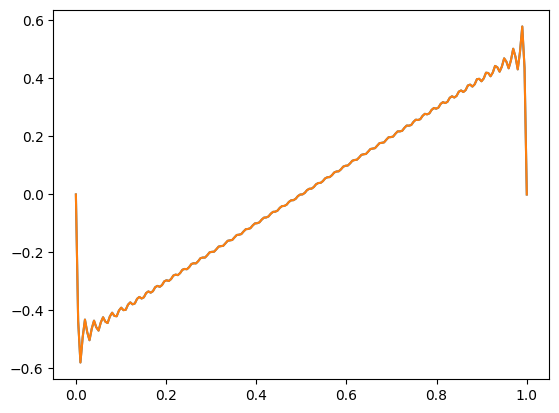

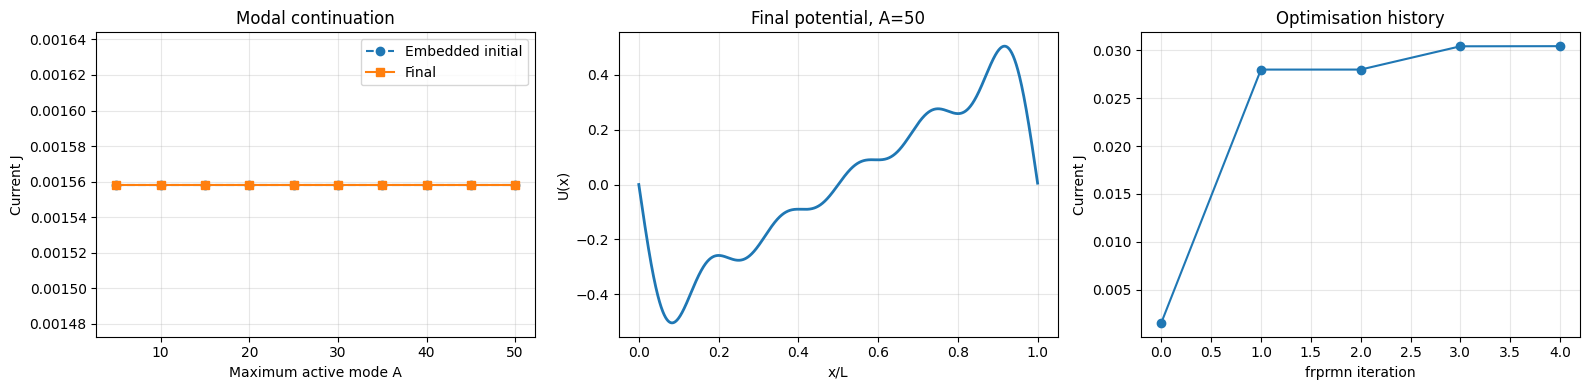

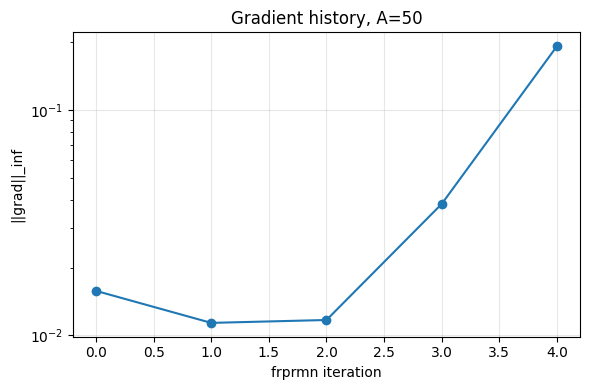


===== Perturbative-order diagnostic =====

 N_nu              J
    3 1.74196587e-03
    5 1.54647446e-03
    7 1.55888065e-03
    9 1.55829795e-03
   11 1.55832011e-03
   13 1.55831942e-03


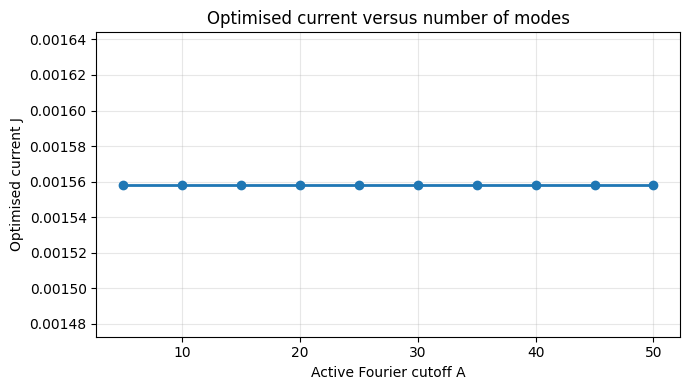

In [ ]:
# Borel resummed code - fully vectorized O(N log N) via fftconvolve

import matplotlib.pyplot as plt
from functools import wraps
import numpy as np
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
import scipy.integrate as integrate
from scipy.optimize import minimize_scalar
from scipy.signal import fftconvolve
import scipy.special as ssp


# using Gunnar's two-mode baseline potential
def initialise_modes(A, L=1.0):  # base shape generator
  a_indices_full = np.arange(-A, A + 1)  # shifted array
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  # initial sawtooth potential as was in the paper
  nonzero = a_indices_full != 0
  U_base[nonzero] = 1j * L**2 / (2.0 * np.pi * a_indices_full[nonzero])

  # plot the potential graph
  x_vals = np.linspace(0, L, 200)
  U_vals = (
      np.sum(
          U_base[:, None]
          * np.exp(
              1j * 2 * np.pi * a_indices_full[:, None] * x_vals[None, :] / L
          ),
          axis=0,
      )
      / L
  )
  plt.plot(x_vals, np.real(U_vals), label="Re(U)")

  return a_indices_full, U_base


def U_modes(theta, U_base, A_k, a_indices_full):
  U_active = np.zeros_like(U_base, dtype=complex)
  index = {int(a): i for i, a in enumerate(a_indices_full)}
  for a in range(1, A_k + 1):
    i = index[a]
    j = index[-a]
    re = theta[2 * (a - 1)]
    im = theta[2 * (a - 1) + 1]
    U_active[i] = re + 1j * im
    U_active[j] = np.conjugate(U_active[i])
  return U_active


def check_radius_of_convergence(coeffs, nu=1.0, min_coefficient=1e-14):
  coeffs = np.asarray(coeffs, dtype=float)

  radii_current = []
  radii_derivative = []

  # Current contains odd orders:
  # J = J1*nu + J3*nu^3 + J5*nu^5 + ...
  for n in range(3, len(coeffs), 2):
    c_previous = coeffs[n - 2]
    c_current = coeffs[n]

    if abs(c_previous) > min_coefficient and abs(c_current) > min_coefficient:
      radius_current = np.sqrt(abs(c_previous / c_current))
      radii_current.append(radius_current)

      # Derivative coefficients are n * J_n
      d_previous = (n - 2) * c_previous
      d_current = n * c_current

      radius_derivative = np.sqrt(abs(d_previous / d_current))
      radii_derivative.append(radius_derivative)

  if len(radii_current) == 0:
    return {
        "radius_current": np.inf,
        "radius_derivative": np.inf,
        "inside_radius": False,
        "radii_current": [],
        "radii_derivative": [],
    }

  # The paper's conservative choice is the minimum
  radius_current = min(radii_current)

  if len(radii_derivative) > 0:
    radius_derivative = min(radii_derivative)
  else:
    radius_derivative = radius_current

  # The derivative radius is the stricter test
  radius_used = min(radius_current, radius_derivative)

  inside_radius = abs(nu) < radius_used

  return {
      "radius_current": radius_current,
      "radius_derivative": radius_derivative,
      "radius_used": radius_used,
      "inside_radius": inside_radius,
      "radii_current": np.asarray(radii_current),
      "radii_derivative": np.asarray(radii_derivative),
  }


def current_series_and_gradient(
    a_indices,
    U_modes,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
):
  N = len(a_indices)  # 2A+1
  k_vals = 2.0 * np.pi * a_indices / L
  P = 2 * A_k

  mode_index = {int(a): i for i, a in enumerate(a_indices)}

  # Fast convolution representation for W
  W_conv = k_vals * U_modes / L

  # construct mode-by-mode gradient helper
  def dU_dtheta(p, b):
    mode = p // 2 + 1
    is_real_part = p % 2 == 0
    if b == mode:
      return 1.0 if is_real_part else 1.0j
    if b == -mode:
      return 1.0 if is_real_part else -1.0j
    return 0.0

  # Construct dW_conv as a 2D matrix of shape (P, N) instead of 3D tensor
  dW_conv = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      dW_conv[p, i] = k_vals[i] * dU_dtheta(p, a) / L

  # calculate Fourier coefficients C_a, C^_a, C_a_
  C = np.zeros(N, dtype=complex)
  C_hat = np.zeros(N, dtype=complex)
  C_under = np.zeros(N, dtype=complex)

  for i, a in enumerate(a_indices):
    if a != 0:
      denom = (
          D**2 * k_vals[i] ** 4
          + w**2 * k_vals[i] ** 2
          + 2 * gamma * k_vals[i] ** 2 * D
      )
      C[i] = (D * k_vals[i] ** 2 + 2 * gamma) * k_vals[i] / denom
      C_hat[i] = 1j * w * k_vals[i] ** 2 / denom
      C_under[i] = D * k_vals[i] ** 2 * k_vals[i] / denom

  # Initialize order-0 fields
  rho = np.zeros(N, dtype=complex)
  m = np.zeros(N, dtype=complex)
  if 0 in a_indices:
    rho[mode_index[0]] = 1.0

  rho_s = np.zeros((P, N), dtype=complex)
  m_s = np.zeros((P, N), dtype=complex)

  # Construct current extraction vector (W_{-a})
  W_minus_a = np.zeros(N, dtype=complex)
  for i, a in enumerate(a_indices):
    minus_a = int(-a)
    if minus_a in mode_index:
      r = mode_index[minus_a]
      W_minus_a[i] = k_vals[r] * U_modes[r] / L

  dW_minus_all = np.zeros((P, N), dtype=complex)
  for p in range(P):
    for i, a in enumerate(a_indices):
      minus_a = int(-a)
      if minus_a in mode_index:
        r = mode_index[minus_a]
        dW_minus_all[p, i] = k_vals[r] * dU_dtheta(p, minus_a) / L

  J_0 = 0.0
  J_1 = (-1j / L) * np.dot(W_minus_a, rho)
  coeffs = [J_0, J_1.real]

  grad_coeffs = [np.zeros(P, dtype=float)]
  grad_J_1 = np.zeros(P, dtype=float)
  for p in range(P):
    dJ_1 = (-1j / L) * np.dot(dW_minus_all[p], rho)
    grad_J_1[p] = dJ_1.real

  grad_coeffs.append(grad_J_1)

  # Vectorized O(N log N) convolution helpers using fftconvolve
  def convolve_1d(a, b):
    full = fftconvolve(a, b, mode="full")
    mid = len(full) // 2
    start = mid - N // 2
    return full[start : start + N]

  def convolve_rows(matrix, vector):
    full = fftconvolve(matrix, vector[None, :], mode="full", axes=-1)
    mid = full.shape[1] // 2
    start = mid - N // 2
    return full[:, start : start + N]

  for order in range(1, N_nu):
    sum_rho = convolve_1d(W_conv, rho)
    sum_m = convolve_1d(W_conv, m)

    rho_next = C_hat * sum_m - C * sum_rho
    m_next = C_hat * sum_rho - C_under * sum_m

    rho_s_next = np.zeros((P, N), dtype=complex)
    m_s_next = np.zeros((P, N), dtype=complex)

    dW_rho = convolve_rows(dW_conv, rho)
    W_rhos = convolve_rows(rho_s, W_conv)
    d_sum_rho = dW_rho + W_rhos

    dW_m = convolve_rows(dW_conv, m)
    W_ms = convolve_rows(m_s, W_conv)
    d_sum_m = dW_m + W_ms

    for p in range(P):
      rho_s_next[p] = C_hat * d_sum_m[p] - C * d_sum_rho[p]
      m_s_next[p] = C_hat * d_sum_rho[p] - C_under * d_sum_m[p]

    J_next = (-1j / L) * np.dot(W_minus_a, rho_next)
    coeffs.append(J_next.real)

    grad_J_next = np.zeros(P, dtype=float)
    for p in range(P):
      dJ_next = (-1j / L) * (
          np.dot(dW_minus_all[p], rho_next) + np.dot(W_minus_a, rho_s_next[p])
      )
      grad_J_next[p] = dJ_next.real
    grad_coeffs.append(grad_J_next)

    rho = rho_next
    m = m_next
    rho_s = rho_s_next
    m_s = m_s_next

  coeffs = np.asarray(coeffs, dtype=float)
  grad_coeffs = np.asarray(grad_coeffs, dtype=float)
  factorials = np.array([ssp.factorial(n) for n in range(len(coeffs))], dtype=float)
  borel_coeffs = coeffs / factorials
  borel_grad_coeffs = grad_coeffs / factorials[:, None]

  def laplace_integrand(z):
    return polyval(nu * z, borel_coeffs) * np.exp(-z)

  def laplace_integrand_grad(z):
    return (
        np.array([polyval(nu * z, borel_grad_coeffs[:, p]) for p in range(P)])
        * np.exp(-z)
    )

  J_total, err = integrate.quad(
      laplace_integrand, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total, grad_err = integrate.quad_vec(
      laplace_integrand_grad, 0, np.inf, limit=1000, epsabs=1e-8, epsrel=1e-8
  )
  grad_J_total = np.asarray(grad_J_total.real, dtype=float)

  if return_coeffs:
    return float(J_total), grad_J_total, coeffs.copy()

  return float(J_total), grad_J_total


A_max = 50
step = 5
L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0
N_nu_val = 50
nu_height = 1.0


def bracket_maximum(
    phi,
    initial_step=1e-2,
    growth=2.0,
    shrink=0.5,
    min_step=1e-14,
    max_alpha=2.0,
    max_iter=50,
):
  alpha_left = 0.0
  phi_left = phi(alpha_left)
  alpha_middle = initial_step
  phi_middle = phi(alpha_middle)
  for _ in range(max_iter):
    if phi_middle > phi_left:
      break
    alpha_middle *= shrink
    if alpha_middle < min_step:
      return None
    phi_middle = phi(alpha_middle)
  else:
    return None
  alpha_right = growth * alpha_middle
  if alpha_right > max_alpha:
    return None
  phi_right = phi(alpha_right)
  for _ in range(max_iter):
    if phi_middle > phi_left and phi_middle > phi_right:
      return (alpha_left, alpha_middle, alpha_right)
    if phi_right > phi_middle:
      alpha_left = alpha_middle
      phi_left = phi_middle
      alpha_middle = alpha_right
      phi_middle = phi_right
      alpha_right *= growth
      if alpha_right > max_alpha:
        return None
      phi_right = phi(alpha_right)
    else:
      return (alpha_left, alpha_middle, alpha_right)
  return None


def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-8,
    ftol=1e-10,
    initial_step=1e-3,
    use_pr_plus=False,
    restart=True,
    verbose=True,
):
  theta = np.asarray(theta0, dtype=float).copy()
  J, grad_J = J_and_grad(theta)
  J = float(J)
  grad_J = np.asarray(grad_J, dtype=float)
  if not np.isfinite(J):
    raise ValueError("Initial current is not finite.")
  if not np.all(np.isfinite(grad_J)):
    raise ValueError("Initial gradient contains NaN or inf.")

  h = grad_J.copy()
  h_norm = np.linalg.norm(h)
  if h_norm > 1e-14:
    h /= h_norm

  history = [{
      "iteration": 0,
      "J": J,
      "grad_norm": np.linalg.norm(grad_J, ord=np.inf),
      "alpha": 0.0,
      "beta": 0.0,
  }]
  converged = False
  stopped_reason = "max iterations reached"

  for iteration in range(1, max_iter + 1):
    grad_norm = np.linalg.norm(grad_J, ord=np.inf)
    if grad_norm < gtol:
      converged = True
      stopped_reason = "gradient tolerance"
      break

    if np.dot(grad_J, h) <= 0.0:
      h = grad_J.copy()
      h_norm = np.linalg.norm(h)
      if h_norm > 1e-14:
        h /= h_norm

    def phi(alpha):
      theta_trial = theta + alpha * h
      J_trial, _ = J_and_grad(theta_trial)
      return float(J_trial)

    bracket = bracket_maximum(phi, initial_step=initial_step)
    if bracket is None:
      h = grad_J.copy()
      h_norm = np.linalg.norm(h)
      if h_norm > 1e-14:
        h /= h_norm
      bracket = bracket_maximum(phi, initial_step=initial_step, max_alpha=1.0)
    if bracket is None:
      stopped_reason = "no improving line-search bracket"
      break

    line_result = minimize_scalar(
        lambda alpha: -phi(alpha),
        bracket=bracket,
        method="brent",
        options={"xtol": 1e-8, "maxiter": 100},
    )
    alpha = float(line_result.x)

    if not np.isfinite(alpha) or alpha <= 0.0:
      stopped_reason = "invalid line-search step"
      break

    theta_new = theta + alpha * h
    J_new, grad_new = J_and_grad(theta_new)
    J_new = float(J_new)
    grad_new = np.asarray(grad_new, dtype=float)

    if not np.isfinite(J_new):
      stopped_reason = "non-finite current after update"
      break
    if not np.all(np.isfinite(grad_new)):
      stopped_reason = "non-finite gradient after update"
      break

    den = np.dot(grad_J, grad_J)
    if den == 0.0:
      beta = 0.0
    else:
      beta = np.dot(grad_new, grad_new - grad_J) / den
    if use_pr_plus:
      beta = max(0.0, beta)
    if not np.isfinite(beta) or beta > 10.0:
      beta = 0.0
    if restart and (iteration % len(theta) == 0):
      beta = 0.0

    h_new = grad_new + beta * h
    h_new_norm = np.linalg.norm(h_new)
    if h_new_norm > 1e-14:
      h_new /= h_new_norm

    relative_change = abs(J_new - J) / (1.0 + abs(J))
    grad_norm_new = np.linalg.norm(grad_new, ord=np.inf)
    history.append({
        "iteration": iteration,
        "J": J_new,
        "grad_norm": grad_norm_new,
        "alpha": alpha,
        "beta": beta,
    })
    if verbose:
      print(
          f"frprmn iteration {iteration:3d}: J={J_new:.12e},"
          f" alpha={alpha:.4e}, beta={beta:.4e},"
          f" ||grad||inf={grad_norm_new:.4e}"
      )
    theta = theta_new
    J = J_new
    grad_J = grad_new
    h = h_new

    if relative_change < ftol:
      converged = True
      stopped_reason = "objective tolerance"
      break

  info = {
      "converged": converged,
      "stopped_reason": stopped_reason,
      "history": history,
      "gradient_norm": np.linalg.norm(grad_J, ord=np.inf),
  }
  return theta, J, info


def optimiser(
    A_max, step, L_domain, D_diff, w_freq, gamma_rtp, N_nu_val, nu_height
):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(A=A_cutoff, L=L_domain)

  n_stages = A_max // step
  theta_opt = None
  stage_results = []
  for k in range(n_stages):
    stage = k + 1
    A_k = (k + 1) * step
    dim_k = 2 * A_k

    theta_init = np.zeros(dim_k, dtype=float)
    if theta_opt is None:
      for a in range(1, A_k + 1):
        i = np.where(a_indices_full == a)[0][0]
        U_a = U_base[i]
        theta_init[2 * (a - 1)] = U_a.real
        theta_init[2 * (a - 1) + 1] = U_a.imag
    else:
      n_old = len(theta_opt)
      if n_old > dim_k:
        raise RuntimeError("Previous parameter vector is larger than current one")
      theta_init[:n_old] = theta_opt
      theta_init[n_old:] = 0.0

    def J_and_grad(theta_vec):
      U_modes_now = U_modes(theta_vec, U_base, A_k, a_indices_full)
      J, grad = current_series_and_gradient(
          a_indices=a_indices_full,
          U_modes=U_modes_now,
          A_k=A_k,
          D=D_diff,
          w=w_freq,
          L=L_domain,
          gamma=gamma_rtp,
          N_nu=N_nu_val,
          nu=nu_height,
      )
      return J, grad

    J_initial, grad_initial = J_and_grad(theta_init)

    print(f"\nStarting stage {stage}/{n_stages}")
    print(f"A_k = {A_k}")
    print(f"Number of parameters = {dim_k}")
    print(f"Initial current = {J_initial:.12e}")
    print(
        "Initial gradient norm ="
        f" {np.linalg.norm(grad_initial, ord=np.inf):.6e}"
    )

    theta_candidate, J_candidate, info = frprmn_maximise(
        theta0=theta_init,
        J_and_grad=J_and_grad,
        max_iter=100,
        gtol=1e-8,
        ftol=1e-10,
        initial_step=1e-2,
        use_pr_plus=True,
        restart=True,
        verbose=True,
    )
    U_candidate = U_modes(theta_candidate, U_base, A_k, a_indices_full)

    J_candidate, grad_candidate, coeffs_candidate = current_series_and_gradient(
        a_indices=a_indices_full,
        U_modes=U_candidate,
        A_k=A_k,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height,
        return_coeffs=True,
    )

    radius_info = check_radius_of_convergence(coeffs_candidate, nu=nu_height)

    radius_used = radius_info["radius_used"]
    inside_radius = radius_info["inside_radius"]
    improves = J_candidate >= J_initial
    finite_candidate = np.isfinite(J_candidate) and np.isfinite(radius_used)
    candidate_stable = finite_candidate and improves and inside_radius

    if candidate_stable:
      theta_opt = theta_candidate.copy()
      J_best = J_candidate
      accepted = True
      status = "accepted"
    else:
      print(
          "Rejecting candidate: "
          f"J={J_candidate:.6e}, radius={radius_used:.6e}, "
          f"|nu|={abs(nu_height):.6e}, inside_radius={inside_radius}, "
          f"improves={improves}"
      )
      theta_opt = theta_init.copy()
      J_best = J_initial
      accepted = False
      status = "rejected: outside radius or no improvement"

    J_final, grad_final = J_and_grad(theta_opt)
    result = {
        "stage": stage,
        "A_k": A_k,
        "theta_initial": theta_init.copy(),
        "theta_opt": theta_opt.copy(),
        "J_initial": J_initial,
        "J_best": J_best,
        "J_final": J_final,
        "gradient_norm": np.linalg.norm(grad_final, ord=np.inf),
        "frprmn_info": info,
        "radius_current": radius_info["radius_current"],
        "radius_derivative": radius_info["radius_derivative"],
        "radius_used": radius_info["radius_used"],
        "inside_radius": radius_info["inside_radius"],
        "accepted": accepted,
        "status": status,
    }

    stage_results.append(result)

    print(
        f"Finished stage {stage}: A_k={A_k}, J_initial={J_initial:.12e},"
        f" J_final={J_final:.12e},"
        f" iterations={info['history'][-1]['iteration'] if 'history' in info and info['history'] else 'N/A'},"
        f" reason={info['stopped_reason']}, radius={radius_info['radius_used']:.6e},"
        f" inside={radius_info['inside_radius']}, status={status}"
    )

  return theta_opt, a_indices_full, U_base, stage_results


a_indices_full, U_base = initialise_modes(A_max, L_domain)
J, grad_J = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_base,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
)

print("J =", J)
print("gradient shape =", grad_J.shape)
print("gradient =", grad_J)

theta_opt, a_indices_full, U_base, stage_results = optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
)

import pandas as pd

table_rows = []
for result in stage_results:
  info = result["frprmn_info"]
  table_rows.append({
      "stage": result["stage"],
      "A": result["A_k"],
      "J_initial": result["J_initial"],
      "J_final": result["J_final"],
      "improvement": result["J_final"] - result["J_initial"],
      "gradient_inf": result["gradient_norm"],
      "iterations": (
          len(info["history"]) - 1 if len(info["history"]) > 0 else 0
      ),
      "status": info["stopped_reason"],
  })

results_table = pd.DataFrame(table_rows)

print("\n===== Modal continuation results =====\n")
print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
        },
    )
)

U_opt = U_modes(theta_opt, U_base, A_max, a_indices_full)

x_plot = np.linspace(0.0, L_domain, 2000, endpoint=False)
k_vals = 2.0 * np.pi * a_indices_full / L_domain

U_opt_x = (
    np.sum(
        U_opt[:, None] * np.exp(1j * k_vals[:, None] * x_plot[None, :]),
        axis=0,
    )
    / L_domain
)

final_info = stage_results[-1]["frprmn_info"]
history = pd.DataFrame(final_info["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(
    results_table["A"], results_table["J_initial"], "o--", label="Embedded initial"
)
axes[0].plot(results_table["A"], results_table["J_final"], "s-", label="Final")
axes[0].set_xlabel("Maximum active mode A")
axes[0].set_ylabel("Current J")
axes[0].set_title("Modal continuation")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_plot / L_domain, U_opt_x.real, linewidth=2.0)
axes[1].set_xlabel("x/L")
axes[1].set_ylabel("U(x)")
axes[1].set_title(f"Final potential, A={A_max}")
axes[1].grid(alpha=0.3)

axes[2].plot(history["iteration"], history["J"], "o-", label="J")
axes[2].set_xlabel("frprmn iteration")
axes[2].set_ylabel("Current J")
axes[2].set_title("Optimisation history")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(history["iteration"], history["grad_norm"], "o-")
plt.xlabel("frprmn iteration")
plt.ylabel("||grad||_inf")
plt.title(f"Gradient history, A={A_max}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

orders = [3, 5, 7, 9, 11, 13]
order_currents = []

for N_test in orders:
  J_test, grad_test = current_series_and_gradient(
      a_indices=a_indices_full,
      U_modes=U_opt,
      A_k=A_max,
      D=D_diff,
      w=w_freq,
      L=L_domain,
      gamma=gamma_rtp,
      N_nu=N_test,
      nu=nu_height,
  )
  order_currents.append(J_test)

order_table = pd.DataFrame({"N_nu": orders, "J": order_currents})

print("\n===== Perturbative-order diagnostic =====\n")
print(order_table.to_string(index=False, formatters={"J": "{:.8e}".format}))

A_values = np.array([result["A_k"] for result in stage_results])
J_values = np.array([result["J_final"] for result in stage_results])

plt.figure(figsize=(7, 4))
plt.plot(A_values, J_values, "o-", linewidth=2, markersize=6)
plt.xlabel("Active Fourier cutoff A")
plt.ylabel("Optimised current J")
plt.title("Optimised current versus number of modes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'initial_theta_from_base' is not defined

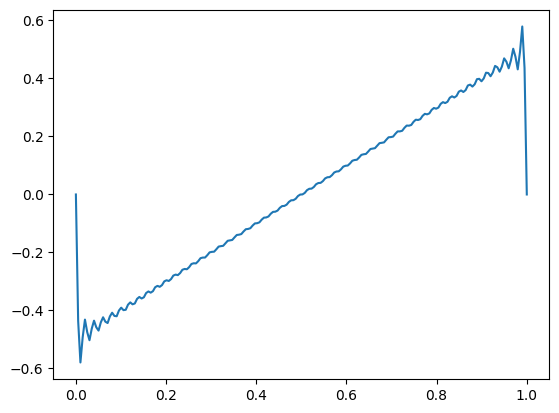

In [ ]:
# Borel resummed code - fully vectorized O(N log N) via fftconvolve

import matplotlib.pyplot as plt
from functools import wraps
import numpy as np
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
import scipy.integrate as integrate
from scipy.optimize import minimize_scalar
from scipy.signal import fftconvolve
from scipy.special import gammainc
import scipy.special as ssp


# using Gunnar's two-mode baseline potential
def initialise_modes(A, L=1.0):  # base shape generator
  a_indices_full = np.arange(-A, A + 1)  # shifted array
  U_base = np.zeros_like(a_indices_full, dtype=complex)

  # initial sawtooth potential as was in the paper
  nonzero = a_indices_full != 0
  U_base[nonzero] = 1j * L**2 / (2.0 * np.pi * a_indices_full[nonzero])

  # plot the potential graph
  x_vals = np.linspace(0, L, 200)
  U_vals = (
      np.sum(
          U_base[:, None]
          * np.exp(
              1j * 2 * np.pi * a_indices_full[:, None] * x_vals[None, :] / L
          ),
          axis=0,
      )
      / L
  )
  plt.plot(x_vals, np.real(U_vals), label="Re(U)")

  return a_indices_full, U_base


def U_modes(theta, U_base, A_k, a_indices_full, kind="imaginary"):
    del U_base
    theta = np.asarray(theta, dtype=float)
    a_indices_full = np.asarray(a_indices_full, dtype=int)
    expected = np.arange(-A_k, A_k + 1)
    if not np.array_equal(a_indices_full, expected):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1).")
    index = {int(a): i for i, a in enumerate(a_indices_full)}
    U_active = np.zeros(2 * A_k + 1, dtype=np.complex128)
    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        for a in range(1, A_k + 1):
            value = 1j * theta[a - 1]
            U_active[index[a]] = value
            U_active[index[-a]] = np.conjugate(value)

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2*A_k-1} parameters, "
                f"received {len(theta)}."
            )

        U_active[index[1]] = 1j * theta[0]
        U_active[index[-1]] = -1j * theta[0]
        for a in range(2, A_k + 1):
            p = a - 1
            U_active[index[a]] += theta[p]
            U_active[index[-a]] += theta[p]
        for a in range(2, A_k + 1):
            p = A_k + a - 2
            U_active[index[a]] += 1j * theta[p]
            U_active[index[-a]] -= 1j * theta[p]
    else:
        raise ValueError("kind must be 'imaginary' or 'full'.")

    return U_active

def derivative_modes_from_theta(
    theta,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (A_k, 2 * A_k + 1),
            dtype=np.complex128,
        )

        for a in range(1, A_k + 1):
            p = a - 1

            U[index[a]] = 1j * theta[p]
            U[index[-a]] = -1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2*A_k-1} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (2 * A_k - 1, 2 * A_k + 1),
            dtype=np.complex128,
        )

        U[index[1]] = 1j * theta[0]
        U[index[-1]] = -1j * theta[0]

        dU[0, index[1]] = 1j
        dU[0, index[-1]] = -1j

        for a in range(2, A_k + 1):
            p = a - 1

            U[index[a]] += theta[p]
            U[index[-a]] += theta[p]

            dU[p, index[a]] = 1.0
            dU[p, index[-a]] = 1.0

        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U[index[a]] += 1j * theta[p]
            U[index[-a]] -= 1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U, dU

def check_radius_of_convergence(
    coeffs,
    nu=1.0,
    min_coefficient=1e-14,
):
    coeffs = np.asarray(
        coeffs,
        dtype=float,
    )

    radii_current = []
    radii_derivative = []

    for n in range(3, len(coeffs), 2):
        j_previous = coeffs[n - 2]
        j_current = coeffs[n]

        if (
            abs(j_previous) > min_coefficient
            and abs(j_current) > min_coefficient
            and np.isfinite(j_previous)
            and np.isfinite(j_current)
        ):
            radii_current.append(
                np.sqrt(
                    abs(
                        j_previous
                        / j_current
                    )
                )
            )

            radii_derivative.append(
                np.sqrt(
                    abs(
                        (n - 2)
                        * j_previous
                        / (
                            n
                            * j_current
                        )
                    )
                )
            )

    if len(radii_current) == 0:
        return {
            "radius_current": np.inf,
            "radius_derivative": np.inf,
            "radius_used": np.inf,
            "inside_radius": True,
            "radii_current": np.array([]),
            "radii_derivative": np.array([]),
        }

    radii_current = np.asarray(
        radii_current,
        dtype=float,
    )

    radii_derivative = np.asarray(
        radii_derivative,
        dtype=float,
    )

    radii_current = radii_current[
        np.isfinite(radii_current)
        & (radii_current > 0.0)
    ]

    radii_derivative = radii_derivative[
        np.isfinite(radii_derivative)
        & (radii_derivative > 0.0)
    ]

    radius_current = (
        float(np.min(radii_current))
        if len(radii_current)
        else np.inf
    )

    radius_derivative = (
        float(np.min(radii_derivative))
        if len(radii_derivative)
        else radius_current
    )

    radius_used = min(
        radius_current,
        radius_derivative,
    )

    return {
        "radius_current": radius_current,
        "radius_derivative": radius_derivative,
        "radius_used": radius_used,
        "inside_radius": bool(
            abs(nu) < radius_used
        ),
        "radii_current": radii_current,
        "radii_derivative": radii_derivative,
    }

def _convolve_rows(
    left,
    right,
):
    return fftconvolve(
        left,
        right,
        mode="full",
        axes=1,
    )


def _derivative_recurrence_step(
    rho,
    mom,
    drho,
    dmom,
    W,
    dW,
    c_hat,
    c_none,
    c_und,
    chunk_size=16,
):
    P = drho.shape[0]

    output_length = (
        drho.shape[1]
        + len(W)
        - 1
    )

    if len(c_hat) != output_length:
        raise ValueError(
            "c_hat length does not match "
            "the convolution output."
        )

    drho_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    dmom_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    for start in range(
        0,
        P,
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            P,
        )

        sl = slice(
            start,
            stop,
        )

        d_rho_w = (
            _convolve_rows(
                drho[sl],
                W[None, :],
            )
            + _convolve_rows(
                rho[None, :],
                dW[sl],
            )
        )

        d_mom_w = (
            _convolve_rows(
                dmom[sl],
                W[None, :],
            )
            + _convolve_rows(
                mom[None, :],
                dW[sl],
            )
        )

        drho_next[sl] = (
            c_hat[None, :] * d_mom_w
            - c_none[None, :] * d_rho_w
        )

        dmom_next[sl] = (
            c_hat[None, :] * d_rho_w
            - c_und[None, :] * d_mom_w
        )

    return (
        drho_next,
        dmom_next,
    )

def current_series_and_gradient(
    a_indices,
    U_modes,
    dU_dtheta,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
    return_details=False,
):
    N_modes = 2 * A_k + 1
    P = dU_dtheta.shape[0]

    a_indices = np.asarray(
        a_indices,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices,
        expected,
    ):
        raise ValueError(
            "a_indices must equal "
            "np.arange(-A_k,A_k+1)."
        )

    k_potential = (
        2.0
        * np.pi
        * a_indices
        / L
    )

    W = (
        k_potential
        * U_modes
        / L
    )

    dW = (
        dU_dtheta
        * k_potential[None, :]
        / L
    )

    U_minus = U_modes[::-1]
    dU_minus = dU_dtheta[:, ::-1]

    prefactor = 1j * k_potential

    rho = np.array(
        [1.0 + 0.0j],
    )

    mom = np.array(
        [0.0 + 0.0j],
    )

    drho = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    dmom = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    terms = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    gradient_terms = np.zeros(
        (N_nu + 1, P),
        dtype=float,
    )

    for recurrence_order in range(
        1,
        N_nu,
    ):
        support = recurrence_order * A_k

        output_modes = np.arange(
            -support,
            support + 1,
        )

        k = (
            2.0
            * np.pi
            * output_modes
            / L
        )

        denominator = (
            D * D * k * k
            + w * w
            + 2.0 * gamma * D
        )

        c_hat = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_none = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_und = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        nonzero = output_modes != 0

        c_hat[nonzero] = (
            1j
            * w
            / denominator[nonzero]
        )

        c_none[nonzero] = (
            D * k[nonzero]**2
            + 2.0 * gamma
        ) / (
            k[nonzero]
            * denominator[nonzero]
        )

        c_und[nonzero] = (
            D
            * k[nonzero]
            / denominator[nonzero]
        )

        rho_w = np.convolve(
            rho,
            W,
        )

        mom_w = np.convolve(
            mom,
            W,
        )

        rho_next = (
            c_hat * mom_w
            - c_none * rho_w
        )

        mom_next = (
            c_hat * rho_w
            - c_und * mom_w
        )

        drho_next, dmom_next = (
            _derivative_recurrence_step(
                rho=rho,
                mom=mom,
                drho=drho,
                dmom=dmom,
                W=W,
                dW=dW,
                c_hat=c_hat,
                c_none=c_none,
                c_und=c_und,
            )
        )

        offset = support

        rho_slice = rho_next[
            offset - A_k :
            offset + A_k + 1
        ]

        drho_slice = drho_next[
            :,
            offset - A_k :
            offset + A_k + 1
        ]

        current_order = recurrence_order + 1

        terms[current_order] = (
            np.sum(
                prefactor
                * U_minus
                * rho_slice
            ).real
            / (L * L)
        )

        gradient_terms[
            current_order
        ] = (
            np.sum(
                prefactor[None, :]
                * (
                    dU_minus
                    * rho_slice[None, :]
                    + U_minus[None, :]
                    * drho_slice
                ),
                axis=1,
            ).real
            / (L * L)
        )

        rho = rho_next
        mom = mom_next
        drho = drho_next
        dmom = dmom_next

    powers = nu ** np.arange(
        N_nu + 1,
    )

    odd_orders = np.arange(
        1,
        N_nu + 1,
        2,
    )

    current = float(
        np.sum(
            terms[odd_orders]
            * powers[odd_orders]
        )
    )

    gradient = np.sum(
        gradient_terms[odd_orders]
        * powers[odd_orders, None],
        axis=0,
    )

    partials = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    running = 0.0

    for n in range(
        N_nu + 1,
    ):
        if n % 2 == 1:
            running += (
                terms[n]
                * powers[n]
            )

        partials[n] = running

    radius_info = (
        check_radius_of_convergence(
            coeffs=terms,
            nu=nu,
        )
    )

    if return_details:
        return {
            "current": current,
            "gradient": gradient,
            "coeffs": terms,
            "gradient_coeffs": gradient_terms,
            "partials": partials,
            "radius": radius_info,
        }

    if return_coeffs:
        return (
            float(current),
            np.asarray(
                gradient,
                dtype=float,
            ),
            terms.copy(),
        )

    return (
        float(current),
        np.asarray(
            gradient,
            dtype=float,
        ),
    )
def cutoff_borel_laplace(
    terms,
    gradient_terms,
    order,
    cutoff,
    nu=1.0,
):
    order = min(
        int(order),
        len(terms) - 1,
    )

    n = np.arange(
        order + 1,
    )

    weights = (
        nu**n
        * gammainc(
            n + 1,
            cutoff,
        )
    )

    current = float(
        np.sum(
            terms[:order + 1]
            * weights
        )
    )

    gradient = np.sum(
        gradient_terms[:order + 1]
        * weights[:, None],
        axis=0,
    )

    return current, gradient

A_max = 50
step = 5
L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0
N_nu_val = 50
nu_height = 1.0


def bracket_maximum(
    phi,
    initial_step=1e-2,
    growth=2.0,
    shrink=0.5,
    min_step=1e-14,
    max_alpha=2.0,
    max_iter=50,
):
  alpha_left = 0.0
  phi_left = phi(alpha_left)
  alpha_middle = initial_step
  phi_middle = phi(alpha_middle)
  for _ in range(max_iter):
    if phi_middle > phi_left:
      break
    alpha_middle *= shrink
    if alpha_middle < min_step:
      return None
    phi_middle = phi(alpha_middle)
  else:
    return None
  alpha_right = growth * alpha_middle
  if alpha_right > max_alpha:
    return None
  phi_right = phi(alpha_right)
  for _ in range(max_iter):
    if phi_middle > phi_left and phi_middle > phi_right:
      return (alpha_left, alpha_middle, alpha_right)
    if phi_right > phi_middle:
      alpha_left = alpha_middle
      phi_left = phi_middle
      alpha_middle = alpha_right
      phi_middle = phi_right
      alpha_right *= growth
      if alpha_right > max_alpha:
        return None
      phi_right = phi(alpha_right)
    else:
      return (alpha_left, alpha_middle, alpha_right)
  return None


def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-8,
    ftol=1e-10,
    initial_step=1e-3,
    use_pr_plus=False,
    restart=True,
    verbose=True,
):
  theta = np.asarray(theta0, dtype=float).copy()
  J, grad_J = J_and_grad(theta)
  J = float(J)
  grad_J = np.asarray(grad_J, dtype=float)
  if not np.isfinite(J):
    raise ValueError("Initial current is not finite.")
  if not np.all(np.isfinite(grad_J)):
    raise ValueError("Initial gradient contains NaN or inf.")

  h = grad_J.copy()
  h_norm = np.linalg.norm(h)
  if h_norm > 1e-14:
    h /= h_norm

  history = [{
      "iteration": 0,
      "J": J,
      "grad_norm": np.linalg.norm(grad_J, ord=np.inf),
      "alpha": 0.0,
      "beta": 0.0,
  }]
  converged = False
  stopped_reason = "max iterations reached"

  for iteration in range(1, max_iter + 1):
    grad_norm = np.linalg.norm(grad_J, ord=np.inf)
    if grad_norm < gtol:
      converged = True
      stopped_reason = "gradient tolerance"
      break

    if np.dot(grad_J, h) <= 0.0:
      h = grad_J.copy()
      h_norm = np.linalg.norm(h)
      if h_norm > 1e-14:
        h /= h_norm

        slope = float(
        np.dot(
            grad_J,
            h,
        )
    )

    if slope <= 0.0:
        h = grad_J.copy()
        h_norm = np.linalg.norm(h)

        if h_norm <= 1e-14:
            stopped_reason = (
                "zero gradient direction"
            )
            break

        h /= h_norm

        slope = float(
            np.dot(
                grad_J,
                h,
            )
        )

    alpha = initial_step
    accepted = False

    for _ in range(30):
        theta_trial = theta + alpha * h

        J_trial, grad_trial = J_and_grad(
            theta_trial,
        )

        if (
            np.isfinite(J_trial)
            and np.all(
                np.isfinite(
                    grad_trial,
                )
            )
            and J_trial
            >= J
            + 1e-4
            * alpha
            * slope
        ):
            accepted = True
            break

        alpha *= 0.5

    if not accepted:
        stopped_reason = (
          "Armijo line-search failure"
        )
        break

    theta_new = theta + alpha * h
    J_new, grad_new = J_and_grad(theta_new)
    J_new = float(J_new)
    grad_new = np.asarray(grad_new, dtype=float)

    if not np.isfinite(J_new):
      stopped_reason = "non-finite current after update"
      break
    if not np.all(np.isfinite(grad_new)):
      stopped_reason = "non-finite gradient after update"
      break

    den = np.dot(grad_J, grad_J)
    if den == 0.0:
      beta = 0.0
    else:
      beta = np.dot(grad_new, grad_new - grad_J) / den
    if use_pr_plus:
      beta = max(0.0, beta)
    if not np.isfinite(beta) or beta > 10.0:
      beta = 0.0
    if restart and (iteration % len(theta) == 0):
      beta = 0.0

    h_new = grad_new + beta * h
    h_new_norm = np.linalg.norm(h_new)
    if h_new_norm > 1e-14:
      h_new /= h_new_norm

    relative_change = abs(J_new - J) / (1.0 + abs(J))
    grad_norm_new = np.linalg.norm(grad_new, ord=np.inf)
    history.append({
        "iteration": iteration,
        "J": J_new,
        "grad_norm": grad_norm_new,
        "alpha": alpha,
        "beta": beta,
    })
    if verbose:
      print(
          f"frprmn iteration {iteration:3d}: J={J_new:.12e},"
          f" alpha={alpha:.4e}, beta={beta:.4e},"
          f" ||grad||inf={grad_norm_new:.4e}"
      )
    theta = theta_new
    J = J_new
    grad_J = grad_new
    h = h_new

    if relative_change < ftol:
      converged = True
      stopped_reason = "objective tolerance"
      break

  info = {
      "converged": converged,
      "stopped_reason": stopped_reason,
      "history": history,
      "gradient_norm": np.linalg.norm(grad_J, ord=np.inf),
  }
  return theta, J, info


def optimiser(
    A_max, step, L_domain, D_diff, w_freq, gamma_rtp, N_nu_val, nu_height
):
  A_cutoff = A_max
  a_indices_full, U_base = initialise_modes(A=A_cutoff, L=L_domain)

  n_stages = A_max // step
  theta_opt = None
  stage_results = []
  for k in range(n_stages):
    stage = k + 1
    A_k = (k + 1) * step
    dim_k = 2 * A_k

    if theta_opt is None:
      theta_init = initial_theta_from_base(
          U_base=U_base,
          a_indices_full=a_indices_full,
          A_k=A_k,
          kind=parameterization_kind,
      )
    else:
      theta_init = pad_theta(
          theta_old=theta_opt,
          old_A=previous_A,
          new_A=A_k,
          a_indices_full=a_indices_full,
          kind=parameterization_kind,
      )

    def J_and_grad(theta_vec):
        U_modes_now, dU_now = (
            derivative_modes_from_theta(
            theta=theta_vec,
            A_k=A_k,
            a_indices_full=a_indices_stage,
            kind=parameterization_kind,
          )
        )

        details = current_series_and_gradient(
            a_indices=a_indices_stage,
            U_modes=U_modes_now,
            dU_dtheta=dU_now,
            A_k=A_k,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_nu_val,
            nu=nu_height,
            return_details=True,
        )

        return (
            details["current"],
            details["gradient"],
        )

    J_initial, grad_initial = J_and_grad(theta_init)

    print(f"\nStarting stage {stage}/{n_stages}")
    print(f"A_k = {A_k}")
    print(f"Number of parameters = {dim_k}")
    print(f"Initial current = {J_initial:.12e}")
    print(
        "Initial gradient norm ="
        f" {np.linalg.norm(grad_initial, ord=np.inf):.6e}"
    )

    theta_candidate, J_candidate, info = frprmn_maximise(
        theta0=theta_init,
        J_and_grad=J_and_grad,
        max_iter=100,
        gtol=1e-8,
        ftol=1e-10,
        initial_step=1e-2,
        use_pr_plus=True,
        restart=True,
        verbose=True,
    )
    U_candidate = U_modes(theta_candidate, U_base, A_k, a_indices_full)

    J_candidate, grad_candidate, coeffs_candidate = current_series_and_gradient(
        a_indices=a_indices_full,
        U_modes=U_candidate,
        A_k=A_k,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_nu_val,
        nu=nu_height,
        return_coeffs=True,
    )

    radius_info = check_radius_of_convergence(coeffs_candidate, nu=nu_height)

    radius_used = radius_info["radius_used"]
    inside_radius = radius_info["inside_radius"]
    improves = J_candidate >= J_initial
    finite_candidate = np.isfinite(J_candidate) and np.isfinite(radius_used)
    candidate_stable = finite_candidate and improves and inside_radius

    if candidate_stable:
      theta_opt = theta_candidate.copy()
      J_best = J_candidate
      accepted = True
      status = "accepted"
    else:
      print(
          "Rejecting candidate: "
          f"J={J_candidate:.6e}, radius={radius_used:.6e}, "
          f"|nu|={abs(nu_height):.6e}, inside_radius={inside_radius}, "
          f"improves={improves}"
      )
      theta_opt = theta_init.copy()
      J_best = J_initial
      accepted = False
      status = "rejected: outside radius or no improvement"

    J_final, grad_final = J_and_grad(theta_opt)
    result = {
        "stage": stage,
        "A_k": A_k,
        "theta_initial": theta_init.copy(),
        "theta_opt": theta_opt.copy(),
        "J_initial": J_initial,
        "J_best": J_best,
        "J_final": J_final,
        "gradient_norm": np.linalg.norm(grad_final, ord=np.inf),
        "frprmn_info": info,
        "radius_current": radius_info["radius_current"],
        "radius_derivative": radius_info["radius_derivative"],
        "radius_used": radius_info["radius_used"],
        "inside_radius": radius_info["inside_radius"],
        "accepted": accepted,
        "status": status,
    }

    stage_results.append(result)

    print(
        f"Finished stage {stage}: A_k={A_k}, J_initial={J_initial:.12e},"
        f" J_final={J_final:.12e},"
        f" iterations={info['history'][-1]['iteration'] if 'history' in info and info['history'] else 'N/A'},"
        f" reason={info['stopped_reason']}, radius={radius_info['radius_used']:.6e},"
        f" inside={radius_info['inside_radius']}, status={status}"
    )

  return theta_opt, a_indices_full, U_base, stage_results


a_indices_full, U_base = initialise_modes(
    A=A_max,
    L=L_domain,
)

theta_initial = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_max,
    kind=parameterization_kind,
)

U_initial, dU_initial = (
    derivative_modes_from_theta(
        theta=theta_initial,
        A_k=A_max,
        a_indices_full=a_indices_full,
        kind=parameterization_kind,
    )
)

initial_details = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_initial,
    dU_dtheta=dU_initial,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    "J =",
    initial_details["current"],
)

print(
    "gradient shape =",
    initial_details["gradient"].shape,
)

print(
    "gradient =",
    initial_details["gradient"],
)

print(
    "radius =",
    initial_details["radius"],
)

print("J =", J)
print("gradient shape =", grad_J.shape)
print("gradient =", grad_J)

coeffs = initial_details["coeffs"]

print("\nFirst perturbative coefficients:")

for n in range(
    min(12, len(coeffs)),
):
    print(
        f"J^({n}) = "
        f"{coeffs[n]: .12e}"
    )

even_orders = np.arange(
    0,
    len(coeffs),
    2,
)

odd_orders = np.arange(
    1,
    len(coeffs),
    2,
)

print(
    "maximum even coefficient =",
    np.max(
        np.abs(
            coeffs[even_orders],
        )
    ),
)

print(
    "maximum odd coefficient =",
    np.max(
        np.abs(
            coeffs[odd_orders],
        )
    ),
)

theta_opt, a_indices_full, U_base, stage_results = optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
)

import pandas as pd

table_rows = []
for result in stage_results:
  info = result["frprmn_info"]
  table_rows.append({
      "stage": result["stage"],
      "A": result["A_k"],
      "J_initial": result["J_initial"],
      "J_final": result["J_final"],
      "improvement": result["J_final"] - result["J_initial"],
      "gradient_inf": result["gradient_norm"],
      "iterations": (
          len(info["history"]) - 1 if len(info["history"]) > 0 else 0
      ),
      "status": info["stopped_reason"],
  })

results_table = pd.DataFrame(table_rows)

print("\n===== Modal continuation results =====\n")
print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
        },
    )
)

U_opt = U_modes(theta_opt, U_base, A_max, a_indices_full)

x_plot = np.linspace(0.0, L_domain, 2000, endpoint=False)
k_vals = 2.0 * np.pi * a_indices_full / L_domain

U_opt_x = (
    np.sum(
        U_opt[:, None] * np.exp(1j * k_vals[:, None] * x_plot[None, :]),
        axis=0,
    )
    / L_domain
)

final_info = stage_results[-1]["frprmn_info"]
history = pd.DataFrame(final_info["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(
    results_table["A"], results_table["J_initial"], "o--", label="Embedded initial"
)
axes[0].plot(results_table["A"], results_table["J_final"], "s-", label="Final")
axes[0].set_xlabel("Maximum active mode A")
axes[0].set_ylabel("Current J")
axes[0].set_title("Modal continuation")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_plot / L_domain, U_opt_x.real, linewidth=2.0)
axes[1].set_xlabel("x/L")
axes[1].set_ylabel("U(x)")
axes[1].set_title(f"Final potential, A={A_max}")
axes[1].grid(alpha=0.3)

axes[2].plot(history["iteration"], history["J"], "o-", label="J")
axes[2].set_xlabel("frprmn iteration")
axes[2].set_ylabel("Current J")
axes[2].set_title("Optimisation history")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(history["iteration"], history["grad_norm"], "o-")
plt.xlabel("frprmn iteration")
plt.ylabel("||grad||_inf")
plt.title(f"Gradient history, A={A_max}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

orders = [3, 5, 7, 9, 11, 13]
order_currents = []

for N_test in orders:
  J_test, grad_test = current_series_and_gradient(
      a_indices=a_indices_full,
      U_modes=U_opt,
      A_k=A_max,
      D=D_diff,
      w=w_freq,
      L=L_domain,
      gamma=gamma_rtp,
      N_nu=N_test,
      nu=nu_height,
  )
  order_currents.append(J_test)

order_table = pd.DataFrame({"N_nu": orders, "J": order_currents})

print("\n===== Perturbative-order diagnostic =====\n")
print(order_table.to_string(index=False, formatters={"J": "{:.8e}".format}))

A_values = np.array([result["A_k"] for result in stage_results])
J_values = np.array([result["J_final"] for result in stage_results])

plt.figure(figsize=(7, 4))
plt.plot(A_values, J_values, "o-", linewidth=2, markersize=6)
plt.xlabel("Active Fourier cutoff A")
plt.ylabel("Optimised current J")
plt.title("Optimised current versus number of modes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Initial current = 0.0022142785322365093
Gradient shape = (250,)
Gradient = [1.39064599e-02 1.67164197e-02 1.27850527e-02 1.00515697e-02
 8.21750199e-03 6.92885087e-03 5.98121417e-03 5.25768338e-03
 4.68827874e-03 4.22902023e-03 3.85103939e-03 3.53466546e-03
 3.26606038e-03 3.03521931e-03 2.83473614e-03 2.65901483e-03
 2.50375029e-03 2.36557768e-03 2.24182973e-03 2.13036534e-03
 2.02944624e-03 1.93764669e-03 1.85378641e-03 1.77688003e-03
 1.70609851e-03 1.64073935e-03 1.58020340e-03 1.52397651e-03
 1.47161504e-03 1.42273414e-03 1.37699836e-03 1.33411398e-03
 1.29382271e-03 1.25589651e-03 1.22013330e-03 1.18635336e-03
 1.15439632e-03 1.12411866e-03 1.09539151e-03 1.06809885e-03
 1.04213595e-03 1.01740801e-03 9.93829060e-04 9.71320888e-04
 9.49812238e-04 9.29238033e-04 9.09538718e-04 8.90659695e-04
 8.72550811e-04 8.55165919e-04 8.38462485e-04 8.22401239e-04
 8.06945872e-04 7.92062759e-04 7.77720717e-04 7.63890788e-04
 7.50546041e-04 7.37661401e-04 7.25213491e-04 7.13180490e-04
 7.0154200

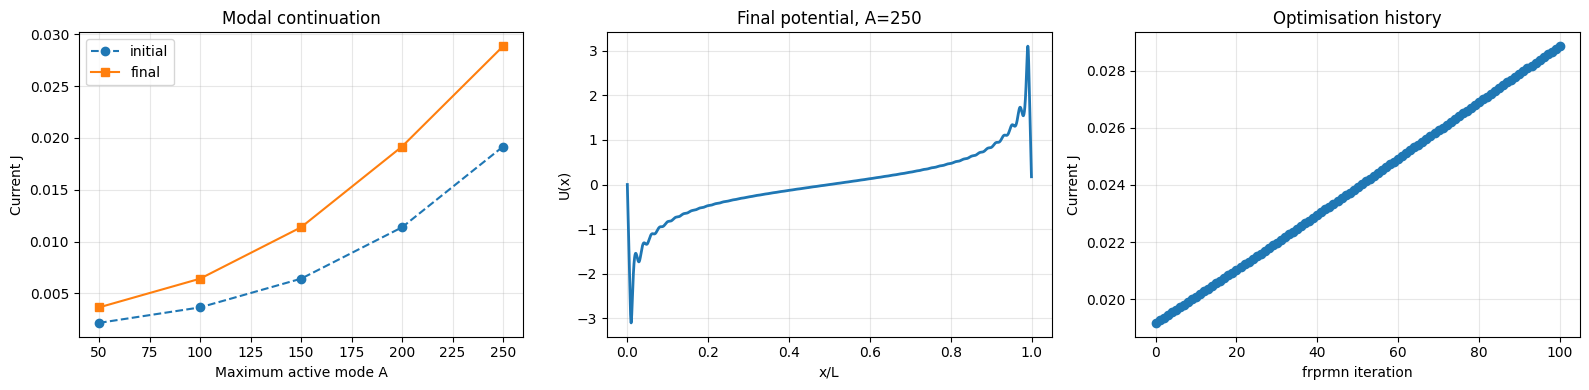

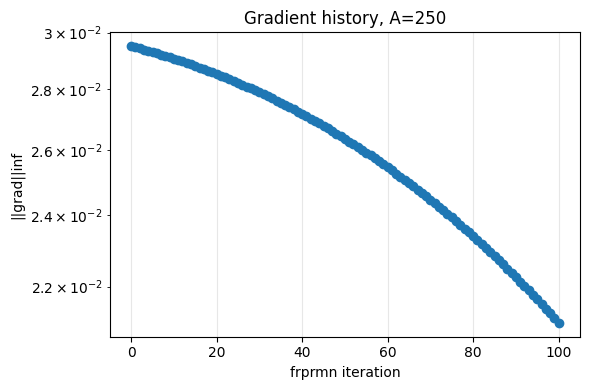


===== Perturbative-order diagnostic =====

 N_nu              J
    3 5.66462977e-02
    5 2.35658635e-02
    7 2.80929762e-02
    9 2.91168050e-02
   11 2.88953301e-02
   13 2.88377212e-02


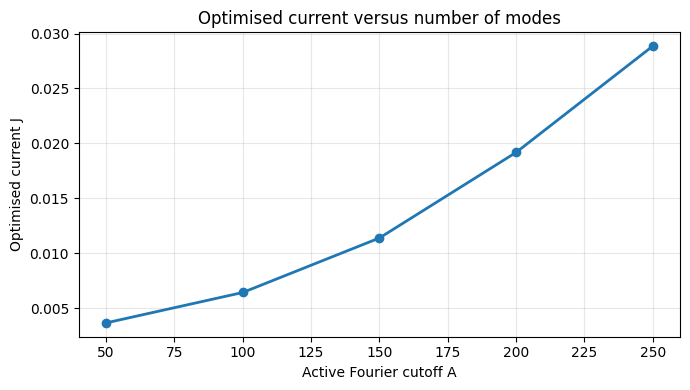

In [ ]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
from scipy.special import gammainc
def initialise_modes(
    A,
    L=1.0,
    plot_initial=True,
):
    a_indices_full = np.arange(
        -A,
        A + 1,
    )

    U_base = np.zeros(
        2 * A + 1,
        dtype=np.complex128,
    )

    # initial sawtooth potential as was in the paper
    nonzero = a_indices_full != 0

    U_base[nonzero] = (
        1j * L**2
        / (
            2.0
            * np.pi
            * a_indices_full[nonzero]
        )
    )

    # plot the potential graph
    if plot_initial:
        x_vals = np.linspace(
            0.0,
            L,
            200,
        )

        U_vals = (
            np.sum(
                U_base[:, None]
                * np.exp(
                    1j
                    * 2.0
                    * np.pi
                    * a_indices_full[:, None]
                    * x_vals[None, :]
                    / L
                ),
                axis=0,
            )
            / L
        )

        plt.plot(
            x_vals,
            U_vals.real,
            label="Re(U)",
        )

    return a_indices_full, U_base
def U_modes(
    theta,
    U_base,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    del U_base

    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U_active = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        for a in range(1, A_k + 1):
            value = 1j * theta[a - 1]

            U_active[index[a]] = value
            U_active[index[-a]] = np.conjugate(value)

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        # U1 is purely imaginary.
        U_active[index[1]] = 1j * theta[0]
        U_active[index[-1]] = -1j * theta[0]

        # Real parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = a - 1

            U_active[index[a]] += theta[p]
            U_active[index[-a]] += theta[p]

        # Imaginary parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U_active[index[a]] += 1j * theta[p]
            U_active[index[-a]] -= 1j * theta[p]

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U_active

def derivative_modes_from_theta(
    theta,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (A_k, 2 * A_k + 1),
            dtype=np.complex128,
        )

        for a in range(1, A_k + 1):
            p = a - 1

            U[index[a]] = 1j * theta[p]
            U[index[-a]] = -1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (2 * A_k - 1, 2 * A_k + 1),
            dtype=np.complex128,
        )

        U[index[1]] = 1j * theta[0]
        U[index[-1]] = -1j * theta[0]

        dU[0, index[1]] = 1j
        dU[0, index[-1]] = -1j

        for a in range(2, A_k + 1):
            p = a - 1

            U[index[a]] += theta[p]
            U[index[-a]] += theta[p]

            dU[p, index[a]] = 1.0
            dU[p, index[-a]] = 1.0

        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U[index[a]] += 1j * theta[p]
            U[index[-a]] -= 1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U, dU

def initial_theta_from_base(
    U_base,
    a_indices_full,
    A_k,
    kind="imaginary",
):
    U_base = np.asarray(
        U_base,
        dtype=np.complex128,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    full_index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    if kind == "imaginary":
        theta = np.zeros(
            A_k,
            dtype=float,
        )

        for a in range(1, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].imag

        return theta

    if kind == "full":
        theta = np.zeros(
            2 * A_k - 1,
            dtype=float,
        )

        theta[0] = U_base[full_index[1]].imag

        for a in range(2, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].real
            theta[A_k + a - 2] = U_base[full_index[a]].imag

        return theta

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def pad_theta(
    theta_old,
    old_A,
    new_A,
    kind,
):
    old_indices = np.arange(
        -old_A,
        old_A + 1,
    )

    old_U = U_modes(
        theta=theta_old,
        U_base=None,
        A_k=old_A,
        a_indices_full=old_indices,
        kind=kind,
    )

    old_index = {
        int(a): i
        for i, a in enumerate(old_indices)
    }

    if kind == "imaginary":
        theta_new = np.zeros(
            new_A,
            dtype=float,
        )

        for a in range(1, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].imag

        return theta_new

    if kind == "full":
        theta_new = np.zeros(
            2 * new_A - 1,
            dtype=float,
        )

        theta_new[0] = old_U[old_index[1]].imag

        for a in range(2, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].real
            theta_new[new_A + a - 2] = old_U[old_index[a]].imag

        return theta_new

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def check_radius_of_convergence(
    coeffs,
    nu=1.0,
):
    coeffs = np.asarray(
        coeffs,
        dtype=float,
    )

    odd = [
        m
        for m in range(3, len(coeffs), 2)
        if np.isfinite(coeffs[m])
        and abs(coeffs[m]) > 0.0
    ]

    if not odd:
        return {
            "radius_current": np.inf,
            "radius_derivative": np.inf,
            "radius_used": np.inf,
            "inside_radius": True,
            "radii_current": np.array([]),
            "radii_derivative": np.array([]),
        }

    largest = odd[-1]

    radius_current = (
        abs(float(coeffs[largest]))
        ** (-1.0 / largest)
    )

    radii_derivative = np.array(
        [
            abs(float(m * coeffs[m]))
            ** (-1.0 / (m - 1))
            for m in odd
        ],
        dtype=float,
    )

    radius_derivative = float(
        np.min(radii_derivative)
    )

    radius_used = min(
        radius_current,
        radius_derivative,
    )

    return {
        "radius_current": float(radius_current),
        "radius_derivative": radius_derivative,
        "radius_used": float(radius_used),
        "inside_radius": bool(
            abs(nu) < radius_used
        ),
        "radii_current": np.array(
            [radius_current],
            dtype=float,
        ),
        "radii_derivative": radii_derivative,
    }
def _convolve_rows(
    left,
    right,
):
    return fftconvolve(
        left,
        right,
        mode="full",
        axes=1,
    )
def _derivative_recurrence_step(
    rho,
    mom,
    drho,
    dmom,
    W,
    dW,
    c_hat,
    c_none,
    c_und,
    chunk_size=16,
):
    P = drho.shape[0]

    output_length = (
        drho.shape[1]
        + len(W)
        - 1
    )

    if len(c_hat) != output_length:
        raise ValueError(
            "c_hat length does not match "
            "the convolution output."
        )

    drho_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    dmom_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    for start in range(
        0,
        P,
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            P,
        )

        sl = slice(
            start,
            stop,
        )

        d_rho_w = (
            _convolve_rows(
                drho[sl],
                W[None, :],
            )
            + _convolve_rows(
                rho[None, :],
                dW[sl],
            )
        )

        d_mom_w = (
            _convolve_rows(
                dmom[sl],
                W[None, :],
            )
            + _convolve_rows(
                mom[None, :],
                dW[sl],
            )
        )

        drho_next[sl] = (
            c_hat[None, :] * d_mom_w
            - c_none[None, :] * d_rho_w
        )

        dmom_next[sl] = (
            c_hat[None, :] * d_rho_w
            - c_und[None, :] * d_mom_w
        )

    return (
        drho_next,
        dmom_next,
    )
def current_series_and_gradient(
    a_indices,
    U_modes,
    dU_dtheta,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
    return_details=False,
):
    a_indices = np.asarray(
        a_indices,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices,
        expected,
    ):
        raise ValueError(
            "a_indices must equal "
            "np.arange(-A_k,A_k+1)."
        )

    U_modes = np.asarray(
        U_modes,
        dtype=np.complex128,
    )

    dU_dtheta = np.asarray(
        dU_dtheta,
        dtype=np.complex128,
    )

    N_modes = 2 * A_k + 1
    P = dU_dtheta.shape[0]

    if U_modes.shape != (N_modes,):
        raise ValueError(
            "U_modes has the wrong shape."
        )

    if dU_dtheta.shape != (
        P,
        N_modes,
    ):
        raise ValueError(
            "dU_dtheta has the wrong shape."
        )

    k_potential = (
        2.0
        * np.pi
        * a_indices
        / L
    )

    W = (
        k_potential
        * U_modes
        / L
    )

    dW = (
        dU_dtheta
        * k_potential[None, :]
        / L
    )

    U_minus = U_modes[::-1]
    dU_minus = dU_dtheta[:, ::-1]
    prefactor = 1j * k_potential

    rho = np.array(
        [1.0 + 0.0j],
    )

    mom = np.array(
        [0.0 + 0.0j],
    )

    drho = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    dmom = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    terms = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    gradient_terms = np.zeros(
        (N_nu + 1, P),
        dtype=float,
    )

    for recurrence_order in range(
        1,
        N_nu,
    ):
        support = recurrence_order * A_k

        output_modes = np.arange(
            -support,
            support + 1,
        )

        k = (
            2.0
            * np.pi
            * output_modes
            / L
        )

        denominator = (
            D * D * k * k
            + w * w
            + 2.0 * gamma * D
        )

        c_hat = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_none = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_und = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        nonzero = output_modes != 0

        c_hat[nonzero] = (
            1j
            * w
            / denominator[nonzero]
        )

        c_none[nonzero] = (
            D * k[nonzero]**2
            + 2.0 * gamma
        ) / (
            k[nonzero]
            * denominator[nonzero]
        )

        c_und[nonzero] = (
            D
            * k[nonzero]
            / denominator[nonzero]
        )

        rho_w = np.convolve(
            rho,
            W,
        )

        mom_w = np.convolve(
            mom,
            W,
        )

        rho_next = (
            c_hat * mom_w
            - c_none * rho_w
        )

        mom_next = (
            c_hat * rho_w
            - c_und * mom_w
        )

        drho_next, dmom_next = (
            _derivative_recurrence_step(
                rho=rho,
                mom=mom,
                drho=drho,
                dmom=dmom,
                W=W,
                dW=dW,
                c_hat=c_hat,
                c_none=c_none,
                c_und=c_und,
            )
        )

        offset = support

        rho_slice = rho_next[
            offset - A_k:
            offset + A_k + 1
        ]

        drho_slice = drho_next[
            :,
            offset - A_k:
            offset + A_k + 1
        ]

        current_order = recurrence_order + 1

        terms[current_order] = (
            np.sum(
                prefactor
                * U_minus
                * rho_slice
            ).real
            / (L * L)
        )

        gradient_terms[current_order] = (
            np.sum(
                prefactor[None, :]
                * (
                    dU_minus
                    * rho_slice[None, :]
                    + U_minus[None, :]
                    * drho_slice
                ),
                axis=1,
            ).real
            / (L * L)
        )

        rho = rho_next
        mom = mom_next
        drho = drho_next
        dmom = dmom_next

    powers = nu ** np.arange(
        N_nu + 1,
    )

    odd_orders = np.arange(
        1,
        N_nu + 1,
        2,
    )

    current = float(
        np.sum(
            terms[odd_orders]
            * powers[odd_orders]
        )
    )

    gradient = np.sum(
        gradient_terms[odd_orders]
        * powers[odd_orders, None],
        axis=0,
    )

    partials = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    running = 0.0

    for n in range(
        N_nu + 1,
    ):
        if n % 2 == 1:
            running += (
                terms[n]
                * powers[n]
            )

        partials[n] = running

    radius_info = (
        check_radius_of_convergence(
            coeffs=terms,
            nu=nu,
        )
    )

    if return_details:
        return {
            "current": float(current),
            "gradient": np.asarray(
                gradient,
                dtype=float,
            ),
            "coeffs": terms,
            "gradient_coeffs": gradient_terms,
            "partials": partials,
            "radius": radius_info,
        }

    if return_coeffs:
        return (
            float(current),
            np.asarray(
                gradient,
                dtype=float,
            ),
            terms.copy(),
        )

    return (
        float(current),
        np.asarray(
            gradient,
            dtype=float,
        ),
    )
def cutoff_borel_laplace(
    terms,
    gradient_terms,
    order,
    cutoff,
    nu=1.0,
):
    order = min(
        int(order),
        len(terms) - 1,
    )

    n = np.arange(
        order + 1,
    )

    weights = (
        nu**n
        * gammainc(
            n + 1,
            cutoff,
        )
    )

    current = float(
        np.sum(
            terms[:order + 1]
            * weights
        )
    )

    gradient = np.sum(
        gradient_terms[:order + 1]
        * weights[:, None],
        axis=0,
    )

    return (
        current,
        np.asarray(
            gradient,
            dtype=float,
        ),
    )

def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-6,
    ftol=1e-10,
    initial_step=1e-2,
    beta_max=1.0,
    ascent_eta=1e-4,
    armijo_c1=1e-4,
    backtrack_factor=0.5,
    verbose=True,
):
    theta = np.asarray(
        theta0,
        dtype=float,
    ).copy()

    J, grad_J = J_and_grad(theta)

    J = float(J)
    grad_J = np.asarray(
        grad_J,
        dtype=float,
    )

    if not np.isfinite(J):
        raise ValueError(
            "Initial current is not finite."
        )

    if not np.all(
        np.isfinite(grad_J)
    ):
        raise ValueError(
            "Initial gradient contains NaN or inf."
        )

    direction = grad_J.copy()

    history = [
        {
            "iteration": 0,
            "J": J,
            "grad_norm": np.linalg.norm(
                grad_J,
                ord=np.inf,
            ),
            "alpha": 0.0,
            "beta": 0.0,
        }
    ]

    converged = False
    stopped_reason = (
        "maximum iterations reached"
    )

    for iteration in range(
        1,
        max_iter + 1,
    ):
        grad_norm = np.linalg.norm(
            grad_J,
            ord=np.inf,
        )

        if grad_norm < gtol:
            converged = True
            stopped_reason = (
                "gradient tolerance"
            )
            break

        slope = float(
            np.dot(
                grad_J,
                direction,
            )
        )

        if slope <= (
            ascent_eta
            * np.dot(
                grad_J,
                grad_J,
            )
        ):
            direction = grad_J.copy()

            slope = float(
                np.dot(
                    grad_J,
                    direction,
                )
            )

        alpha = initial_step
        accepted = False

        for _ in range(30):
            theta_trial = (
                theta
                + alpha * direction
            )

            J_trial, grad_trial = (
                J_and_grad(
                    theta_trial,
                )
            )

            if (
                np.isfinite(J_trial)
                and np.all(
                    np.isfinite(grad_trial)
                )
                and J_trial
                >= J
                + armijo_c1
                * alpha
                * slope
            ):
                accepted = True
                break

            alpha *= backtrack_factor

        if not accepted:
            stopped_reason = (
                "Armijo line-search failure"
            )
            break

        theta_new = (
            theta
            + alpha * direction
        )

        J_new, grad_new = (
            J_and_grad(theta_new)
        )

        J_new = float(J_new)
        grad_new = np.asarray(
            grad_new,
            dtype=float,
        )

        if not np.isfinite(J_new):
            stopped_reason = (
                "non-finite current after update"
            )
            break

        if not np.all(
            np.isfinite(grad_new)
        ):
            stopped_reason = (
                "non-finite gradient after update"
            )
            break

        denominator = max(
            float(
                np.dot(
                    grad_J,
                    grad_J,
                )
            ),
            1e-30,
        )

        beta_pr = float(
            np.dot(
                grad_new,
                grad_new - grad_J,
            )
            / denominator
        )

        beta = min(
            beta_max,
            max(
                0.0,
                beta_pr,
            )
        )

        direction_new = (
            grad_new
            + beta * direction
        )

        if np.dot(
            grad_new,
            direction_new,
        ) <= (
            ascent_eta
            * np.dot(
                grad_new,
                grad_new,
            )
        ):
            direction_new = grad_new.copy()
            beta = 0.0

        relative_change = (
            abs(J_new - J)
            / max(
                1.0,
                abs(J),
            )
        )

        history.append(
            {
                "iteration": iteration,
                "J": J_new,
                "grad_norm": np.linalg.norm(
                    grad_new,
                    ord=np.inf,
                ),
                "alpha": alpha,
                "beta": beta,
            }
        )

        if verbose:
            print(
                f"frprmn iteration {iteration:3d}: "
                f"J={J_new:.12e}, "
                f"alpha={alpha:.4e}, "
                f"beta={beta:.4e}, "
                f"||grad||inf="
                f"{np.linalg.norm(grad_new, ord=np.inf):.4e}"
            )

        theta = theta_new
        J = J_new
        grad_J = grad_new
        direction = direction_new

        if relative_change < ftol:
            converged = True
            stopped_reason = (
                "objective tolerance"
            )
            break

    info = {
        "converged": converged,
        "stopped_reason": stopped_reason,
        "history": history,
        "gradient_norm": np.linalg.norm(
            grad_J,
            ord=np.inf,
        ),
        "iterations": len(history) - 1,
    }

    return theta, J, info

def optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
    parameterization_kind="imaginary",
):
    a_indices_full, U_base = initialise_modes(
        A=A_max,
        L=L_domain,
        plot_initial=False,
    )

    n_stages = A_max // step
    theta_opt = None
    previous_A = None
    stage_results = []

    for k in range(n_stages):
        stage = k + 1
        A_k = (k + 1) * step

        a_indices_stage = np.arange(
            -A_k,
            A_k + 1,
        )

        if parameterization_kind == "imaginary":
            dim_k = A_k
        elif parameterization_kind == "full":
            dim_k = 2 * A_k - 1
        else:
            raise ValueError(
                "Invalid parameterization_kind."
            )

        if theta_opt is None:
            theta_init = initial_theta_from_base(
                U_base=U_base,
                a_indices_full=a_indices_full,
                A_k=A_k,
                kind=parameterization_kind,
            )
        else:
            theta_init = pad_theta(
                theta_old=theta_opt,
                old_A=previous_A,
                new_A=A_k,
                kind=parameterization_kind,
            )

        def J_and_grad(theta_vec):
            U_modes_now, dU_now = (
                derivative_modes_from_theta(
                    theta=theta_vec,
                    A_k=A_k,
                    a_indices_full=a_indices_stage,
                    kind=parameterization_kind,
                )
            )

            details = current_series_and_gradient(
                a_indices=a_indices_stage,
                U_modes=U_modes_now,
                dU_dtheta=dU_now,
                A_k=A_k,
                D=D_diff,
                w=w_freq,
                L=L_domain,
                gamma=gamma_rtp,
                N_nu=N_nu_val,
                nu=nu_height,
                return_details=True,
            )

            return (
                details["current"],
                details["gradient"],
            )

        J_initial, grad_initial = (
            J_and_grad(theta_init)
        )

        print(
            f"\nStarting stage "
            f"{stage}/{n_stages}"
        )

        print(
            f"A_k = {A_k}"
        )

        print(
            f"Number of parameters = {dim_k}"
        )

        print(
            f"Initial current = "
            f"{J_initial:.12e}"
        )

        print(
            "Initial gradient norm = "
            f"{np.linalg.norm(grad_initial, ord=np.inf):.6e}"
        )

        theta_candidate, J_candidate, info = (
            frprmn_maximise(
                theta0=theta_init,
                J_and_grad=J_and_grad,
                max_iter=100,
                gtol=1e-6,
                ftol=1e-10,
                initial_step=1e-2,
                beta_max=1.0,
                ascent_eta=1e-4,
                armijo_c1=1e-4,
                verbose=True,
            )
        )

        U_candidate, dU_candidate = (
            derivative_modes_from_theta(
                theta=theta_candidate,
                A_k=A_k,
                a_indices_full=a_indices_stage,
                kind=parameterization_kind,
            )
        )

        candidate_details = current_series_and_gradient(
            a_indices=a_indices_stage,
            U_modes=U_candidate,
            dU_dtheta=dU_candidate,
            A_k=A_k,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_nu_val,
            nu=nu_height,
            return_details=True,
        )

        J_candidate = candidate_details["current"]
        coeffs_candidate = candidate_details["coeffs"]
        radius_info = candidate_details["radius"]

        improves = (
            J_candidate
            >= J_initial
        )

        finite_candidate = (
            np.isfinite(J_candidate)
            and np.all(
                np.isfinite(
                    coeffs_candidate
                )
            )
        )

        candidate_stable = (
            finite_candidate
            and improves
            and radius_info["inside_radius"]
        )

        if candidate_stable:
            theta_opt = theta_candidate.copy()
            J_best = J_candidate
            accepted = True
            status = "accepted"
        else:
            print(
                "Rejecting candidate: "
                f"J={J_candidate:.6e}, "
                f"radius="
                f"{radius_info['radius_used']:.6e}, "
                f"|nu|={abs(nu_height):.6e}, "
                f"inside_radius="
                f"{radius_info['inside_radius']}, "
                f"improves={improves}"
            )

            theta_opt = theta_init.copy()
            J_best = J_initial
            accepted = False
            status = (
                "rejected: outside radius "
                "or no improvement"
            )

        J_final, grad_final = J_and_grad(theta_opt)

        result = {
            "stage": stage,
            "A_k": A_k,
            "theta_initial": theta_init.copy(),
            "theta_opt": theta_opt.copy(),
            "J_initial": J_initial,
            "J_best": J_best,
            "J_final": J_final,
            "gradient_norm": np.linalg.norm(
                grad_final,
                ord=np.inf,
            ),
            "frprmn_info": info,
            "radius_current": radius_info[
                "radius_current"
            ],
            "radius_derivative": radius_info[
                "radius_derivative"
            ],
            "radius_used": radius_info[
                "radius_used"
            ],
            "inside_radius": radius_info[
                "inside_radius"
            ],
            "accepted": accepted,
            "status": status,
        }

        stage_results.append(result)

        print(
            f"Finished stage {stage}: "
            f"A_k={A_k}, "
            f"J_initial={J_initial:.12e}, "
            f"J_final={J_final:.12e}, "
            f"iterations={info['iterations']}, "
            f"reason={info['stopped_reason']}, "
            f"radius={radius_info['radius_used']:.6e}, "
            f"inside={radius_info['inside_radius']}, "
            f"status={status}"
        )

        previous_A = A_k

    return (
        theta_opt,
        a_indices_full,
        U_base,
        stage_results,
    )
A_max = 250
step = 50

L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0

N_nu_val = 75
nu_height = 1.0

# Use "full" for a low-mode audit.
# Use "imaginary" for the high-mode continuation.
parameterization_kind = "imaginary"

a_indices_full, U_base = initialise_modes(
    A=A_max,
    L=L_domain,
    plot_initial=False,
)

theta_initial = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_max,
    kind=parameterization_kind,
)

U_initial, dU_initial = (
    derivative_modes_from_theta(
        theta=theta_initial,
        A_k=A_max,
        a_indices_full=a_indices_full,
        kind=parameterization_kind,
    )
)

initial_details = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_initial,
    dU_dtheta=dU_initial,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    "Initial current =",
    initial_details["current"],
)

print(
    "Gradient shape =",
    initial_details["gradient"].shape,
)

print(
    "Gradient =",
    initial_details["gradient"],
)

print(
    "Radius =",
    initial_details["radius"],
)
coeffs = initial_details["coeffs"]

print("\nFirst perturbative coefficients:\n")

for n in range(
    min(12, len(coeffs)),
):
    print(
        f"J^({n}) = "
        f"{coeffs[n]: .12e}"
    )

even_orders = np.arange(
    0,
    len(coeffs),
    2,
)

odd_orders = np.arange(
    1,
    len(coeffs),
    2,
)

max_even = np.max(
    np.abs(
        coeffs[even_orders]
    )
)

max_odd = np.max(
    np.abs(
        coeffs[odd_orders]
    )
)

print(
    "\nMaximum even coefficient =",
    max_even,
)

print(
    "Maximum odd coefficient =",
    max_odd,
)

print(
    "Even/odd coefficient ratio =",
    max_even / max(
        max_odd,
        1e-30,
    ),
)
def finite_difference_gradient_check(
    theta,
    objective,
    epsilon=2e-6,
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    analytic = objective(theta)["gradient"]

    finite_difference = np.zeros_like(
        theta,
        dtype=float,
    )

    for p in range(len(theta)):
        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[p] += epsilon
        theta_minus[p] -= epsilon

        J_plus = objective(theta_plus)["current"]
        J_minus = objective(theta_minus)["current"]

        finite_difference[p] = (
            J_plus - J_minus
        ) / (2.0 * epsilon)

    difference = (
        analytic
        - finite_difference
    )

    relative_error = (
        np.linalg.norm(difference)
        / max(
            np.linalg.norm(
                finite_difference
            ),
            1e-14,
        )
    )

    return {
        "analytic": analytic,
        "finite_difference": finite_difference,
        "relative_error": relative_error,
        "max_absolute_error": np.max(
            np.abs(difference)
        ),
    }
A_audit = min(
    3,
    A_max,
)

a_indices_audit = np.arange(
    -A_audit,
    A_audit + 1,
)

theta_audit = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_audit,
    kind="full",
)


def audit_objective(theta):
    U_audit, dU_audit = (
        derivative_modes_from_theta(
            theta=theta,
            A_k=A_audit,
            a_indices_full=a_indices_audit,
            kind="full",
        )
    )

    details = current_series_and_gradient(
        a_indices=a_indices_audit,
        U_modes=U_audit,
        dU_dtheta=dU_audit,
        A_k=A_audit,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=min(N_nu_val, 15),
        nu=nu_height,
        return_details=True,
    )

    return {
        "current": details["current"],
        "gradient": details["gradient"],
    }
gradient_audit = finite_difference_gradient_check(
    theta=theta_audit,
    objective=audit_objective,
    epsilon=2e-6,
)

print(
    "\n===== Gradient audit ====="
)

print(
    "Relative gradient error =",
    gradient_audit["relative_error"],
)

print(
    "Maximum absolute gradient error =",
    gradient_audit["max_absolute_error"],
)

print(
    "Analytic gradient =",
    gradient_audit["analytic"],
)

print(
    "Finite-difference gradient =",
    gradient_audit["finite_difference"],
)
theta_opt, a_indices_full, U_base, stage_results = (
    optimiser(
        A_max=A_max,
        step=step,
        L_domain=L_domain,
        D_diff=D_diff,
        w_freq=w_freq,
        gamma_rtp=gamma_rtp,
        N_nu_val=N_nu_val,
        nu_height=nu_height,
        parameterization_kind=parameterization_kind,
    )
)
a_indices_final = np.arange(
    -A_max,
    A_max + 1,
)

U_opt, dU_opt = (
    derivative_modes_from_theta(
        theta=theta_opt,
        A_k=A_max,
        a_indices_full=a_indices_final,
        kind=parameterization_kind,
    )
)

final_details = current_series_and_gradient(
    a_indices=a_indices_final,
    U_modes=U_opt,
    dU_dtheta=dU_opt,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    "\n===== Final result ====="
)

print(
    "Final current =",
    final_details["current"],
)

print(
    "Final gradient norm =",
    np.linalg.norm(
        final_details["gradient"],
        ord=np.inf,
    ),
)

print(
    "Final radius =",
    final_details["radius"],
)
table_rows = []

for result in stage_results:
    info = result["frprmn_info"]

    table_rows.append(
        {
            "stage": result["stage"],
            "A": result["A_k"],
            "J_initial": result["J_initial"],
            "J_final": result["J_final"],
            "improvement": (
                result["J_final"]
                - result["J_initial"]
            ),
            "gradient_inf": result[
                "gradient_norm"
            ],
            "iterations": info[
                "iterations"
            ],
            "radius": result[
                "radius_used"
            ],
            "inside_radius": result[
                "inside_radius"
            ],
            "status": info[
                "stopped_reason"
            ],
        }
    )

results_table = pd.DataFrame(
    table_rows,
)

print(
    "\n===== Modal continuation results =====\n"
)

print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
            "radius": "{:.6e}".format,
        },
    )
)
x_plot = np.linspace(
    0.0,
    L_domain,
    2000,
    endpoint=False,
)

k_vals = (
    2.0
    * np.pi
    * a_indices_final
    / L_domain
)

U_opt_x = (
    np.sum(
        U_opt[:, None]
        * np.exp(
            1j
            * k_vals[:, None]
            * x_plot[None, :]
        ),
        axis=0,
    )
    / L_domain
)
final_info = stage_results[-1][
    "frprmn_info"
]

history = pd.DataFrame(
    final_info["history"]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

axes[0].plot(
    results_table["A"],
    results_table["J_initial"],
    "o--",
    label="initial",
)

axes[0].plot(
    results_table["A"],
    results_table["J_final"],
    "s-",
    label="final",
)

axes[0].set_xlabel(
    "Maximum active mode A"
)

axes[0].set_ylabel(
    "Current J"
)

axes[0].set_title(
    "Modal continuation"
)

axes[0].grid(
    alpha=0.3,
)

axes[0].legend()

axes[1].plot(
    x_plot / L_domain,
    U_opt_x.real,
    linewidth=2.0,
)

axes[1].set_xlabel(
    "x/L"
)

axes[1].set_ylabel(
    "U(x)"
)

axes[1].set_title(
    f"Final potential, A={A_max}"
)

axes[1].grid(
    alpha=0.3,
)

axes[2].plot(
    history["iteration"],
    history["J"],
    "o-",
)

axes[2].set_xlabel(
    "frprmn iteration"
)

axes[2].set_ylabel(
    "Current J"
)

axes[2].set_title(
    "Optimisation history"
)

axes[2].grid(
    alpha=0.3,
)

fig.tight_layout()
plt.show()
plt.figure(
    figsize=(6, 4),
)

plt.semilogy(
    history["iteration"],
    history["grad_norm"],
    "o-",
)

plt.xlabel(
    "frprmn iteration"
)

plt.ylabel(
    "||grad||inf"
)

plt.title(
    f"Gradient history, A={A_max}"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()
orders = [
    3,
    5,
    7,
    9,
    11,
    13,
]

order_currents = []

for N_test in orders:
    test_details = current_series_and_gradient(
        a_indices=a_indices_final,
        U_modes=U_opt,
        dU_dtheta=dU_opt,
        A_k=A_max,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_test,
        nu=nu_height,
        return_details=True,
    )

    order_currents.append(
        test_details["partials"][N_test]
    )

order_table = pd.DataFrame(
    {
        "N_nu": orders,
        "J": order_currents,
    }
)

print(
    "\n===== Perturbative-order diagnostic =====\n"
)

print(
    order_table.to_string(
        index=False,
        formatters={
            "J": "{:.8e}".format,
        },
    )
)
A_values = np.array(
    [
        result["A_k"]
        for result in stage_results
    ]
)

J_values = np.array(
    [
        result["J_final"]
        for result in stage_results
    ]
)

plt.figure(
    figsize=(7, 4),
)

plt.plot(
    A_values,
    J_values,
    "o-",
    linewidth=2,
    markersize=6,
)

plt.xlabel(
    "Active Fourier cutoff A"
)

plt.ylabel(
    "Optimised current J"
)

plt.title(
    "Optimised current versus number of modes"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()
